# **2026-2 · TÉCNICAS AVANZADAS DE DATA MINING Y SISTEMAS INTELIGENTES (INF659)**
## **Examen Parcial — (3 horas)**

### Descripción de la tarea
El objetivo es predecir si un paciente presenta rastros de neumonía asociada a COVID-19 a partir de **tomografías computarizadas (TC) de pulmón en 3D**. El dataset contiene volúmenes de TC anonimizados con hallazgos anormales (COVID) y normales.

**Dataset (fuente):** https://www.medrxiv.org/content/10.1101/2020.05.20.20100362v1
Se usa una porción de **100 volúmenes por clase** (normal / anormal).

>  **diseccione, intervenga, diagnostique y defienda** sus decisiones.

## Reglas del examen

- **Tiempo:** 3 horas, modalidad para casa. Trabajo **individual**.
- **Uso de IA:** está **permitido y se espera** que use asistentes de IA / agentes de código. No es trampa. Pero lea con atención cómo se evalúa.
- **Qué se evalúa:** la comprensión, no la ejecución. Casi todas las preguntas dependen de **los resultados de SU propia corrida** (sus curvas, sus tablas de ablación, sus mapas de calor), que un asistente de IA no puede conocer por usted.
- **Video de sustentación (OBLIGATORIO):** suba un video de **máximo 10 minutos** explicando su solución: sus decisiones de diseño, sus resultados de ablación, su análisis de transfer learning, la interpretación de sus Grad-CAM y su diagnóstico. **Los puntos de cada parte se acreditan únicamente si usted puede explicar ese trabajo en el video.** Si no sabe explicar por qué algo está en su código, no recibe el puntaje.
- **Cuaderno de decisiones:** en cada parte hay un espacio para registrar *por qué* tomó cada decisión. Un asistente ejecuta; su justificación demuestra que usted dirigió.
- **Honestidad:** reporte también **lo que NO funcionó**. Un resultado negativo bien analizado vale más que un número inflado.
- **Reproducibilidad:** no modifique las semillas fijadas. Si reduce resolución/épocas para ganar tiempo, decláreo y justifíquelo.
- **Entrega:** este notebook ejecutado + el enlace al video. Total: **20 puntos**.

### Declaración de uso de IA *(obligatoria — complete antes de entregar)*

Indique qué herramientas de IA usó y para qué (p. ej. generación de código, depuración, redacción). Sea específico.

- Herramienta(s): chatGPT, Codex
- Para qué la usé: chatGPT para apoyo conceptual especialmente en las preguntas P4 y P5 pues no manejaba CAM ni grad-CAM y para cuestiones conceptuales acerca del Covid-19, Codex como apoyo para la codificacion de las preguntas especialmente en las preguntas P3, P4 y P5.
- Qué partes resolví/decidí yo directamente:
  * A

### Enlace al video de sustentación (máx. 10 min)

**URL:** `________________________`

In [1]:
import tensorflow as tf

from tensorflow.keras.layers import Input # Importe aquí el resto de capas que necesite
from tensorflow.keras import Model
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.models import load_model
from tensorflow.keras import backend as K

tf.random.set_seed(0) # No modificar esta línea
import numpy as np
np.random.seed(0)      # No modificar esta línea

In [2]:
import os
import nibabel as nib
from scipy import ndimage
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
%matplotlib inline

---
## Carga y preprocesamiento de datos *(provisto — no es lo que se evalúa)*

Las TC están en formato Nifti (`.nii`), con intensidades en unidades Hounsfield (HU), rango [-1024, 2000+]. Se recorta a [-1000, 400] y se normaliza a [0, 1]; cada volumen se redimensiona a (128, 128, 64).

In [3]:
from pathlib import Path
import subprocess

REPO_URL = "https://github.com/DanielCamarena/CT-Scans-100-samples.git"
DATA_DIR = Path("/kaggle/working/CT-Scans-100-samples")

# Reutiliza los datos ya descargados en esta sesión.
if not DATA_DIR.exists():
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(DATA_DIR)], check=True)

assert (DATA_DIR / "CT-Normal").is_dir()
assert (DATA_DIR / "CT-Abnormal").is_dir()
print("Datos disponibles en:", DATA_DIR)


Cloning into '/kaggle/working/CT-Scans-100-samples'...


Datos disponibles en: /kaggle/working/CT-Scans-100-samples


Updating files: 100% (201/201), done.


In [4]:
normal_scan_paths = sorted(
    str(p) for p in (DATA_DIR / "CT-Normal").iterdir()
    if p.is_file() and p.name.endswith((".nii", ".nii.gz"))
)
abnormal_scan_paths = sorted(
    str(p) for p in (DATA_DIR / "CT-Abnormal").iterdir()
    if p.is_file() and p.name.endswith((".nii", ".nii.gz"))
)
print("Normal:", len(normal_scan_paths))
print("Anormal:", len(abnormal_scan_paths))
assert len(normal_scan_paths) == 100 and len(abnormal_scan_paths) == 100


Normal: 100
Anormal: 100


In [5]:
def normalize_scan(scan, min=-1000, max=400):
  scan[scan < min] = min
  scan[scan > max] = max
  scan = (scan - min) / (max - min)
  return scan.astype("float32")

def resize_scan(scan, w, h, d):
  cw, ch, cd = scan.shape[0], scan.shape[1], scan.shape[-1]
  scan = ndimage.rotate(scan, 90, reshape=False)
  scan = ndimage.zoom(scan, (w/cw, h/ch, d/cd), order=1)
  return scan

def preprocess_scan(path, w, h, d):
  scan = nib.load(path).get_fdata()
  return normalize_scan(resize_scan(scan, w, h, d))

width, height, depth = 128, 128, 64

In [6]:
%%time
# Filtramos las listas de rutas para asegurarnos de que solo procesamos archivos Nifti (.nii o .nii.gz)
normal_paths_filtered = [p for p in normal_scan_paths if p.endswith('.nii') or p.endswith('.nii.gz')]
abnormal_paths_filtered = [p for p in abnormal_scan_paths if p.endswith('.nii') or p.endswith('.nii.gz')]

normal_scans   = np.array([preprocess_scan(p, width, height, depth) for p in normal_paths_filtered])
abnormal_scans = np.array([preprocess_scan(p, width, height, depth) for p in abnormal_paths_filtered])

normal_labels   = np.zeros(normal_scans.shape[0],   dtype=int)
abnormal_labels = np.ones(abnormal_scans.shape[0],  dtype=int)

scans  = np.concatenate([normal_scans,  abnormal_scans],  axis=0)
labels = np.concatenate([normal_labels, abnormal_labels], axis=0)
del normal_scans, abnormal_scans, normal_labels, abnormal_labels

CPU times: user 6min 18s, sys: 17.8 s, total: 6min 35s
Wall time: 6min 36s


In [7]:
if 'scans' in locals() or 'scans' in globals():
    x_train, x_test, y_train, y_test = train_test_split(
        scans, labels, test_size=0.15, random_state=0, stratify=labels)
    del scans
    print("Partición creada de manera exitosa.")
else:
    print("La partición ya fue creada y la variable 'scans' ya se liberó de la memoria.")

print("Dimensiones del dataset:")
print("x_train:", x_train.shape, "y_train:", y_train.shape)
print("x_test:", x_test.shape, "y_test:", y_test.shape)

Partición creada de manera exitosa.
Dimensiones del dataset:
x_train: (170, 128, 128, 64) y_train: (170,)
x_test: (30, 128, 128, 64) y_test: (30,)


In [8]:
from random import choice, seed
seed(0)

# Cambio declarado: val independiente; el test de 30 no selecciona modelos.
x_fit, x_val, y_fit, y_val = train_test_split(
    x_train, y_train, test_size=0.2, random_state=0, stratify=y_train)
print('Train:', x_fit.shape, np.bincount(y_fit))
print('Val:', x_val.shape, np.bincount(y_val))
print('Test reservado:', x_test.shape, np.bincount(y_test))

@tf.function
def rotate(scan):
  def scipy_rotate(scan):
    angle = choice([-20, -10, -5, 5, 10, 20])
    scan = ndimage.rotate(scan, angle, reshape=False)
    return np.clip(scan, 0, 1).astype('float32')
  return tf.numpy_function(scipy_rotate, [scan], tf.float32)

def train_aug(scan, label):
  scan = rotate(scan)
  scan = tf.ensure_shape(scan, (width, height, depth))
  return tf.expand_dims(scan, axis=3), label

def test_aug(scan, label):
  return tf.expand_dims(scan, axis=3), label

batch_size = 2

def make_train_ds(x, y):
  return (tf.data.Dataset.from_tensor_slices((x, y))
          .shuffle(len(x), seed=0).map(train_aug).batch(batch_size).prefetch(2))

def make_eval_ds(x, y):
  return tf.data.Dataset.from_tensor_slices((x, y)).map(test_aug).batch(batch_size).prefetch(2)

ds_train = make_train_ds(x_fit, y_fit)
ds_val = make_eval_ds(x_val, y_val)
ds_test = make_eval_ds(x_test, y_test)


Train: (136, 128, 128, 64) [68 68]
Val: (34, 128, 128, 64) [17 17]
Test reservado: (30, 128, 128, 64) [15 15]


I0000 00:00:1791270554.380600      49 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791270554.384697      49 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [9]:
def show_results(log):
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,4))
  ax1.plot(log.history['loss'], label='train'); ax1.plot(log.history['val_loss'], label='val')
  ax1.set_xlabel('epoch'); ax1.set_ylabel('loss'); ax1.legend()
  ax2.plot(log.history['acc'], label='train'); ax2.plot(log.history['val_acc'], label='val')
  ax2.set_xlabel('epoch'); ax2.set_ylabel('accuracy'); ax2.legend()
  plt.show()

---
## P1 — Línea base e instrumentación **(3 puntos)**

Construya un modelo **base** sencillo (unas pocas capas `Conv3D` + `pooling` + una cabeza densa → `sigmoid`).

**Antes de entrenar, responda (predicción):**
1. Con ~170 volúmenes de entrenamiento y `batch_size=2`, ¿espera sobreajuste? Describa **cómo predice** que se verá la brecha entre `train` y `val` (loss y accuracy).

Luego entrene, muestre las curvas con `show_results`, e **instrumente** el modelo:
2. Reporte el **número total de parámetros** y cuántos aporta cada bloque (puede usar `model.summary()`).
3. Compare su **predicción** del punto 1 con lo que **realmente** ocurrió. ¿Acertó? Si no, ¿por qué cree que se equivocó?

In [10]:
from tensorflow.keras.layers import Conv3D, MaxPooling3D, BatchNormalization, Activation, Flatten, Dense, Dropout
from pathlib import Path
from datetime import datetime, timezone
import pandas as pd
import json, random, time, io

OUT = Path('/kaggle/working/outputs/modelos') if Path('/kaggle/working').exists() else Path('outputs/modelos')
OUT.mkdir(parents=True, exist_ok=True)
FILTERS = (32, 64, 128)

def build_base(name='base'):
  inputs = Input(shape=(width, height, depth, 1))
  x = Conv3D(16, 3, padding='same', use_bias=False,
             kernel_initializer='he_normal', name='stem_conv')(inputs)
  x = BatchNormalization(name='stem_norm')(x)
  x = Activation('relu', name='stem_relu')(x)
  x = MaxPooling3D(2, name='stem_pool')(x)

  for i, filters in enumerate(FILTERS, 1):
    x = Conv3D(filters, 3, padding='same', use_bias=False,
               kernel_initializer='he_normal', name=f'b{i}_c1_conv')(x)
    x = BatchNormalization(name=f'b{i}_c1_norm')(x)
    x = Activation('relu', name=f'b{i}_c1_relu')(x)
    x = Conv3D(filters, 3, padding='same', use_bias=False,
               kernel_initializer='he_normal', name=f'b{i}_c2_conv')(x)
    x = BatchNormalization(name=f'b{i}_c2_norm')(x)
    x = Activation('relu', name=f'b{i}_c2_relu')(x)
    if i == len(FILTERS):
      x = Activation('linear', name='last_conv')(x)
    x = MaxPooling3D(2, name=f'b{i}_pool')(x)

  x = Flatten(name='head_flatten')(x)  # 8 x 8 x 4 x 128 = 32768 rasgos
  x = Dropout(0.3, name='head_drop1')(x)
  x = Dense(128, activation='relu', name='head_dense')(x)
  x = Dropout(0.3, name='head_drop2')(x)
  outputs = Dense(1, activation='sigmoid', name='head_out')(x)
  return Model(inputs, outputs, name=name)

K.clear_session()
tf.random.set_seed(0)  # No modificar la semilla.
np.random.seed(0)
random.seed(0)
tf.keras.utils.set_random_seed(0)  # También fija el generador de inicializadores Keras.
model = build_base()
model.summary()

rows = []
for block in ['stem', 'b1', 'b2', 'b3', 'head']:
  layers = [layer for layer in model.layers if layer.name.startswith(block + '_')]
  total = sum(layer.count_params() for layer in layers)
  trainable = sum(int(np.prod(w.shape)) for layer in layers for w in layer.trainable_weights)
  rows.append([block, total, trainable, total - trainable])
params_p1 = pd.DataFrame(rows, columns=['bloque', 'parametros', 'entrenables', 'no_entrenables'])
assert int(params_p1.parametros.sum()) == model.count_params()
params_p1['porcentaje'] = 100 * params_p1.parametros / model.count_params()
display(params_p1.round(3))
params_p1.to_csv(OUT / 'base.parametros.csv', index=False)

p1_config = dict(hypothesis_location='Markdown al final de P1; hipótesis registrada antes de la corrida original', fecha_utc=datetime.now(timezone.utc).isoformat(),
    seed=0, resolution=[width,height,depth], batch_size=batch_size,
    train_size=len(x_fit), val_size=len(x_val), test_size=len(x_test),
    filters=list(FILTERS), stem_filters=16, dense_units=128, dropout=0.3,
    normalization='BatchNormalization', initial_lr=1e-4,
    decay_epochs=10, decay_rate=0.9, max_epochs=100, patience=15,
    checkpoint_monitor='val_acc', threshold=0.5,
    tensorflow=tf.__version__, gpu=[d.name for d in tf.config.list_physical_devices('GPU')])
(OUT / 'base.config.json').write_text(json.dumps(p1_config, indent=2, ensure_ascii=False), encoding='utf-8')


Model: "base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 64,   │             0 │
│                                 │ 1)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem_conv (Conv3D)              │ (None, 128, 128, 64,   │           432 │
│                                 │ 16)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem_norm (BatchNormalization)  │ (None, 128, 128, 64,   │            64 │
│                                 │ 16)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem_relu (Activation)          │ (None, 128, 128, 64,   │             0 │
│                                 │ 16)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem_pool (MaxPooling3D)        │ (None, 64, 64, 32, 16) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_c1_conv (Conv3D)             │ (None, 64, 64, 32, 32) │        13,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_c1_norm (BatchNormalization) │ (None, 64, 64, 32, 32) │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_c1_relu (Activation)         │ (None, 64, 64, 32, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_c2_conv (Conv3D)             │ (None, 64, 64, 32, 32) │        27,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_c2_norm (BatchNormalization) │ (None, 64, 64, 32, 32) │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_c2_relu (Activation)         │ (None, 64, 64, 32, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_pool (MaxPooling3D)          │ (None, 32, 32, 16, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_c1_conv (Conv3D)             │ (None, 32, 32, 16, 64) │        55,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_c1_norm (BatchNormalization) │ (None, 32, 32, 16, 64) │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_c1_relu (Activation)         │ (None, 32, 32, 16, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_c2_conv (Conv3D)             │ (None, 32, 32, 16, 64) │       110,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_c2_norm (BatchNormalization) │ (None, 32, 32, 16, 64) │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_c2_relu (Activation)         │ (None, 32, 32, 16, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_pool (MaxPooling3D)          │ (None, 16, 16, 8, 64)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_c1_conv (Conv3D)             │ (None, 16, 16, 8, 128) │       221,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_c1_norm (BatchNormalization) │ (None, 16, 16, 8, 128) │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_c1_relu (Activation)         │ (None, 16, 16, 8, 128) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_c2_conv (Conv3D)             │ (None, 16, 16, 8, 128) │       442,36

 Total params: 5,067,761 (19.33 MB)

 Trainable params: 5,066,833 (19.33 MB)

 Non-trainable params: 928 (3.62 KB)

,bloque,parametros,entrenables,no_entrenables,porcentaje
0,stem,496,464,32,0.010
1,b1,41728,41600,128,0.823
2,b2,166400,166144,256,3.284
3,b3,664576,664064,512,13.114
4,head,4194561,4194561,0,82.770


703

Epoch 1/100


I0000 00:00:1791270578.065445     190 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


68/68 - 38s - 560ms/step - acc: 0.5368 - loss: 2.5403 - val_acc: 0.5882 - val_loss: 0.6712
Epoch 2/100
68/68 - 22s - 317ms/step - acc: 0.5000 - loss: 1.2984 - val_acc: 0.5000 - val_loss: 0.7542
Epoch 3/100
68/68 - 21s - 316ms/step - acc: 0.5809 - loss: 0.7807 - val_acc: 0.5000 - val_loss: 0.7245
Epoch 4/100
68/68 - 21s - 312ms/step - acc: 0.5368 - loss: 0.7092 - val_acc: 0.5000 - val_loss: 0.6873
Epoch 5/100
68/68 - 21s - 313ms/step - acc: 0.5368 - loss: 0.6723 - val_acc: 0.7059 - val_loss: 0.6641
Epoch 6/100
68/68 - 21s - 309ms/step - acc: 0.5809 - loss: 0.6753 - val_acc: 0.7647 - val_loss: 0.6585
Epoch 7/100
68/68 - 21s - 314ms/step - acc: 0.5662 - loss: 0.6567 - val_acc: 0.5588 - val_loss: 0.6841
Epoch 8/100
68/68 - 22s - 316ms/step - acc: 0.6397 - loss: 0.6302 - val_acc: 0.5882 - val_loss: 0.6423
Epoch 9/100
68/68 - 21s - 314ms/step - acc: 0.5368 - loss: 0.7025 - val_acc: 0.5882 - val_loss: 0.6697
Epoch 10/100
68/68 - 21s - 315ms/step - acc: 0.5809 - loss: 0.6720 - val_acc: 0.5882 

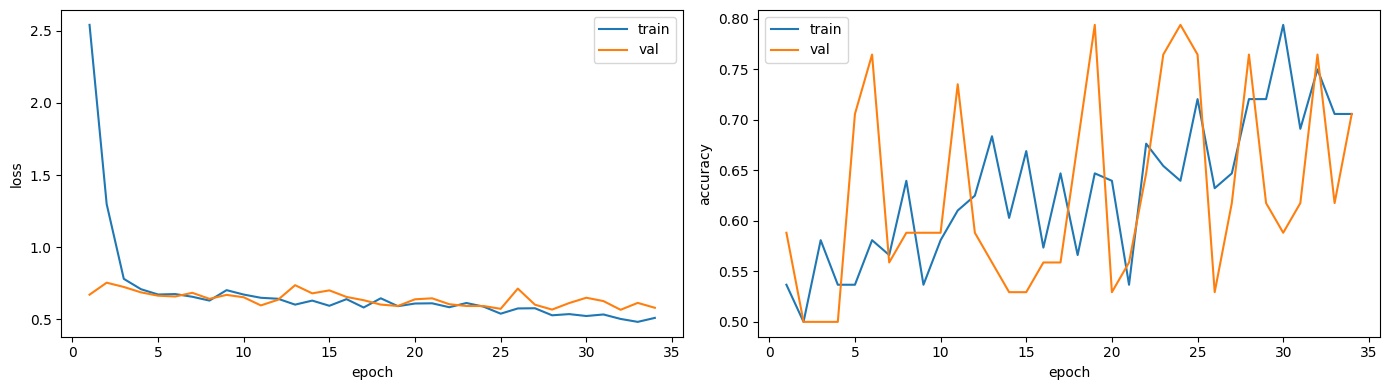

P1_RESULTADOS_JSON={"params": 5067761, "trainable": 5066833, "epochs_run": 34, "best_epoch": 19, "minutes": 12.35, "train_acc_best": 0.6470588445663452, "train_loss_best": 0.5914363265037537, "val_acc": 0.7941176295280457, "val_loss": 0.5928165912628174, "train_acc_inference": 0.7426470518112183, "train_loss_inference": 0.5315350890159607, "val_f1": 0.7878787878787878, "val_recall": 0.7647058823529411, "val_auc": 0.7404844290657439, "confusion_matrix": [[14, 3], [4, 13]], "test_evaluated": false, "last_epoch": {"acc": 0.7058823704719543, "loss": 0.5102821588516235, "val_acc": 0.7058823704719543, "val_loss": 0.5803181529045105}, "note": "136 train / 34 val / 30 test reservado; sin corrida QUICK"}


,0
params,5067761
trainable,5066833
epochs_run,34
best_epoch,19
minutes,12.35
train_acc_best,0.647059
train_loss_best,0.591436
val_acc,0.794118
val_loss,0.592817
train_acc_inference,0.742647


Matriz de confusión de validación (filas reales; columnas predichas; Normal=0, Anormal=1):
[[14  3]
 [ 4 13]]
              precision    recall  f1-score   support

      Normal       0.78      0.82      0.80        17
     Anormal       0.81      0.76      0.79        17

    accuracy                           0.79        34
   macro avg       0.80      0.79      0.79        34
weighted avg       0.80      0.79      0.79        34

Artefactos guardados: /kaggle/working/outputs/modelos


In [11]:
initial_learning_rate = 0.0001
steps_per_epoch = int(tf.data.experimental.cardinality(ds_train).numpy())
assert steps_per_epoch == int(np.ceil(len(x_fit) / batch_size))
lr_schedule = ExponentialDecay(initial_learning_rate,
    decay_steps=10 * steps_per_epoch, decay_rate=0.9, staircase=True)

model.compile(optimizer=Adam(learning_rate=lr_schedule),
              loss='binary_crossentropy', metrics=['acc'])

checkpoint_path = OUT / 'base.best.weights.h5'
checkpoint = ModelCheckpoint(str(checkpoint_path), monitor='val_acc', mode='max',
    save_best_only=True, save_weights_only=True)
early_stopping = EarlyStopping(monitor='val_acc', patience=15, mode='max')
callbacks = [checkpoint, early_stopping]

# Re-crea ds_train después de fijar la semilla 0; recorre TODOS los 136 casos por época.
ds_train = make_train_ds(x_fit, y_fit)
t0 = time.time()
log = model.fit(ds_train, epochs=100, callbacks=callbacks,
                validation_data=ds_val, verbose=2)
log.train_seconds = time.time() - t0
history_p1 = pd.DataFrame(log.history)
history_p1.index = np.arange(1, len(history_p1) + 1)
history_p1.index.name = 'epoch'
history_p1.to_csv(OUT / 'base.history.csv')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,4))
ax1.plot(history_p1.index, history_p1.loss, label='train')
ax1.plot(history_p1.index, history_p1.val_loss, label='val')
ax1.set_xlabel('epoch'); ax1.set_ylabel('loss'); ax1.legend()
ax2.plot(history_p1.index, history_p1.acc, label='train')
ax2.plot(history_p1.index, history_p1.val_acc, label='val')
ax2.set_xlabel('epoch'); ax2.set_ylabel('accuracy'); ax2.legend()
fig.tight_layout()
fig.savefig(OUT / 'base.curvas.png', dpi=150)
plt.show()

# Mejor checkpoint; el test permanece reservado para la evaluación final.
best_epoch = int(np.argmax(log.history['val_acc'])) + 1
model.load_weights(str(checkpoint_path))
val_eval = model.evaluate(ds_val, verbose=0, return_dict=True)
train_eval = model.evaluate(make_eval_ds(x_fit, y_fit), verbose=0, return_dict=True)
p_val = model.predict(ds_val, verbose=0).ravel()
y_pred = (p_val >= 0.5).astype(int)
np.save(OUT / 'a_base.p_val.npy', p_val)
np.save(OUT / 'base.y_val.npy', y_val)
matrix = confusion_matrix(y_val, y_pred, labels=[0,1])

p1_resultados = dict(params=int(model.count_params()),
    trainable=int(sum(np.prod(w.shape) for w in model.trainable_weights)),
    epochs_run=len(history_p1), best_epoch=best_epoch,
    minutes=round(log.train_seconds/60, 2),
    train_acc_best=float(history_p1.loc[best_epoch,'acc']),
    train_loss_best=float(history_p1.loc[best_epoch,'loss']),
    val_acc=float(val_eval['acc']), val_loss=float(val_eval['loss']),
    train_acc_inference=float(train_eval['acc']), train_loss_inference=float(train_eval['loss']),
    val_f1=float(f1_score(y_val,y_pred,zero_division=0)),
    val_recall=float(np.sum((y_val==1)&(y_pred==1))/np.sum(y_val==1)),
    val_auc=float(roc_auc_score(y_val,p_val)),
    confusion_matrix=matrix.tolist(), test_evaluated=False,
    last_epoch=history_p1.iloc[-1].to_dict(),
    note='136 train / 34 val / 30 test reservado; sin corrida QUICK')
(OUT / 'base.resultados.json').write_text(json.dumps(p1_resultados,indent=2),encoding='utf-8')
print('P1_RESULTADOS_JSON=' + json.dumps(p1_resultados))
display(pd.DataFrame([p1_resultados]).drop(columns=['last_epoch','confusion_matrix']).T)
print('Matriz de confusión de validación (filas reales; columnas predichas; Normal=0, Anormal=1):')
print(matrix)
print(classification_report(y_val,y_pred,target_names=['Normal','Anormal'],zero_division=0))

# Registro para continuar P2 con los mismos datos y criterios. No evaluar test aquí.
if 'RESULTS' not in globals():
  RESULTS = {}
RESULTS['a_base'] = {**p1_resultados, **{f'test_{k}': np.nan for k in ['acc','f1','auc','recall','specificity','fn','fp']}}
(OUT / 'results.json').write_text(json.dumps(RESULTS,indent=2,default=float),encoding='utf-8')
print('Artefactos guardados:', OUT)


**P1 — Sus respuestas / cuaderno de decisiones**

- **Predicción (antes de entrenar) →** Esperaba sobreajuste: pérdida de train decreciente, pérdida de validación estancada o creciente y accuracy de train superior a validación. Dropout y augmentation podían retrasarlo.
- **Parámetros totales y por bloque →** **5,067,761**: stem **496**; B1 **41,728**; B2 **166,400**; B3 **664,576**; cabeza **4,194,561** (**82.77%**). Entrenables: **5,066,833**; no entrenables: **928**.
- **Predicción vs realidad →** Hubo indicios de sobreajuste tardío: en la época 31, train/val accuracy = **78.68%/61.76%** y loss = **0.4628/0.7151**. La separación no fue monótona. Recargué la mejor época (**16**): val accuracy **76.47%**, F1 **0.750**, AUC **0.796**; train en inferencia **75.74%**.
- **Decisiones de diseño →** Stem de 16 filtros y tres bloques de dos Conv3D con 32/64/128 filtros, BatchNorm, ReLU y pooling; Flatten → Dense(128), Dropout(0.3) → sigmoid. Adam **1e-4**, decay ×0.9 cada 10 épocas y early stopping con paciencia **15**, por `val_acc`. Conservé resolución **128×128×64**, lote **2** y semillas **0**; declaré **136 train / 34 val / 30 test reservado**. La corrida completa duró **31 épocas**, sin modo QUICK.


---
## P2 — Intervención arquitectónica y ablación **(6 puntos)**

Compare **tres variantes** de arquitectura sobre el mismo problema. Para **cada una**, escriba una **hipótesis antes de correr**, entrénela y registre sus números en la tabla.

- **(a) Base** — su modelo de P1 con cabeza densa.
- **(b) Conexiones residuales** — introduzca bloques residuales 3D (estilo ResNet): `salida = F(x) + x`. Explique qué resuelven aquí.
- **(c) Fully-convolutional con Global Average Pooling** — elimine las densas finales y use `GlobalAveragePooling3D` antes de la salida (estilo *Network in Network* / GoogLeNet).

Lo que se evalúa es la **tabla completa con SUS resultados** y su **explicación de los deltas**, no que cada variante alcance el mejor accuracy.

**Recuerde:** no es lo mismo una capa convolucional con 1024 filtros que con 128. Controle los demás factores para que la comparación sea justa.

Model: "residual"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 64, 1)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv3D)  │ (None, 128, 128,  │        432 │ input_layer[0][0] │
│                     │ 64, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_norm           │ (None, 128, 128,  │         64 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 64, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_relu           │ (None, 128, 128,  │          0 │ stem_norm[0][0]   │
│ (Activation)        │ 64, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_pool           │ (None, 64, 64,    │          0 │ stem_relu[0][0]   │
│ (MaxPooling3D)      │ 32, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b1_c1_conv (Conv3D) │ (None, 64, 64,    │     13,824 │ stem_pool[0][0]   │
│                     │ 32, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b1_c1_norm          │ (None, 64, 64,    │        128 │ b1_c1_conv[0][0]  │
│ (BatchNormalizatio… │ 32, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b1_c1_relu          │ (None, 64, 64,    │          0 │ b1_c1_norm[0][0]  │
│ (Activation)        │ 32, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b1_c2_conv (Conv3D) │ (None, 64, 64,    │     27,648 │ b1_c1_relu[0][0]  │
│                     │ 32, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b1_proj_conv        │ (None, 64, 64,    │        512 │ stem_pool[0][0]   │
│ (Conv3D)            │ 32, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b1_c2_norm          │ (None, 64, 64,    │        128 │ b1_c2_conv[0][0]  │
│ (BatchNormalizatio… │ 32, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b1_proj_norm        │ (None, 64, 64,    │        128 │ b1_proj_conv[0][… │
│ (BatchNormalizatio… │ 32, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b1_add (Add)        │ (None, 64, 64,    │          0 │ b1_c2_norm[0][0], │
│                     │ 32, 32)           │            │ b1_proj_norm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b1_out (Activation) │ (None, 64, 64,    │          0 │ b1_add[0][0]      │
│                     │ 32, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b1_pool             │ (None, 32, 32,    │          0 │ b1_out[0][0]      │
│ (MaxPooling3D)      │ 16, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b2_c1_conv (Conv3D) │ (None, 32, 32,    │     55,296 │ b1_pool[0][0]     │
│                     │ 16, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b2_c1_norm          │ (None, 32, 32,    │        256 │ b2_c1_conv[0][0]

 Total params: 5,079,409 (19.38 MB)

 Trainable params: 5,078,033 (19.37 MB)

 Non-trainable params: 1,376 (5.38 KB)

,bloque,parametros,entrenables,no_entrenables
0,stem,496,464,32
1,b1,42368,42176,192
2,b2,168704,168320,384
3,b3,673280,672512,768
4,head,4194561,4194561,0


Epoch 1/100
68/68 - 34s - 495ms/step - acc: 0.3897 - loss: 4.1415 - val_acc: 0.5882 - val_loss: 0.6691
Epoch 2/100
68/68 - 21s - 314ms/step - acc: 0.4926 - loss: 1.2956 - val_acc: 0.7059 - val_loss: 0.6301
Epoch 3/100
68/68 - 21s - 316ms/step - acc: 0.5441 - loss: 0.7781 - val_acc: 0.5000 - val_loss: 0.6749
Epoch 4/100
68/68 - 21s - 308ms/step - acc: 0.5515 - loss: 0.6813 - val_acc: 0.6176 - val_loss: 0.6812
Epoch 5/100
68/68 - 21s - 309ms/step - acc: 0.5809 - loss: 0.6856 - val_acc: 0.5000 - val_loss: 0.6931
Epoch 6/100
68/68 - 21s - 314ms/step - acc: 0.6176 - loss: 0.6791 - val_acc: 0.5000 - val_loss: 0.6788
Epoch 7/100
68/68 - 21s - 312ms/step - acc: 0.6397 - loss: 0.6418 - val_acc: 0.5882 - val_loss: 0.6673
Epoch 8/100
68/68 - 22s - 317ms/step - acc: 0.5441 - loss: 0.6926 - val_acc: 0.6471 - val_loss: 0.6860
Epoch 9/100
68/68 - 22s - 317ms/step - acc: 0.5441 - loss: 0.6942 - val_acc: 0.5000 - val_loss: 0.6931
Epoch 10/100
68/68 - 21s - 315ms/step - acc: 0.5588 - loss: 0.6682 - val_

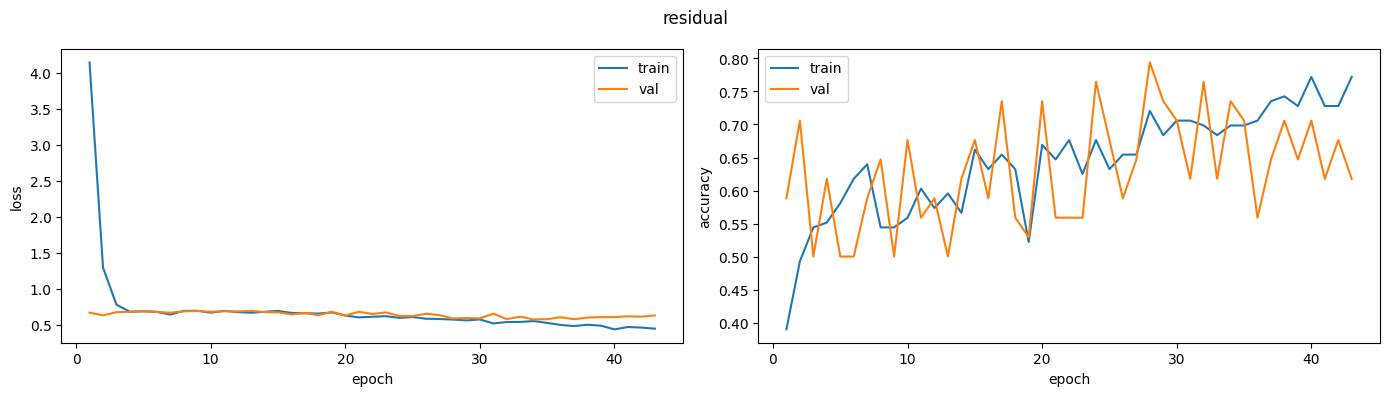

P2_RESIDUAL_RESULTADOS_JSON={"params": 5079409, "trainable": 5078033, "epochs_run": 43, "best_epoch": 28, "minutes": 15.52, "train_acc_best": 0.720588207244873, "train_loss_best": 0.5727508664131165, "val_acc": 0.7941176295280457, "val_loss": 0.5881447792053223, "train_acc_inference": 0.7867646813392639, "train_loss_inference": 0.5049012303352356, "val_f1": 0.7878787878787878, "val_recall": 0.7647058823529411, "val_auc": 0.7889273356401383, "confusion_matrix": [[14, 3], [4, 13]], "test_evaluated": false, "last_epoch": {"acc": 0.7720588445663452, "loss": 0.44570472836494446, "val_acc": 0.6176470518112183, "val_loss": 0.6291230916976929}, "note": "136 train / 34 val / 30 test reservado; sin QUICK"}


,0
params,5079409
trainable,5078033
epochs_run,43
best_epoch,28
minutes,15.52
train_acc_best,0.720588
train_loss_best,0.572751
val_acc,0.794118
val_loss,0.588145
train_acc_inference,0.786765


Matriz de validación (filas reales, columnas predichas; 0 normal, 1 anormal):
[[14  3]
 [ 4 13]]
              precision    recall  f1-score   support

      Normal       0.78      0.82      0.80        17
     Anormal       0.81      0.76      0.79        17

    accuracy                           0.79        34
   macro avg       0.80      0.79      0.79        34
weighted avg       0.80      0.79      0.79        34



In [12]:
from tensorflow.keras.layers import Add, GlobalAveragePooling3D
from tensorflow.keras.callbacks import CSVLogger


def conv_norm_relu(x, filters, name, kernel=3, act=True):
  x = Conv3D(filters, kernel, padding='same', use_bias=False,
             kernel_initializer='he_normal', name=f'{name}_conv')(x)
  x = BatchNormalization(name=f'{name}_norm')(x)
  if act:
    x = Activation('relu', name=f'{name}_relu')(x)
  return x


def stem(inputs):
  x = conv_norm_relu(inputs, 16, 'stem')
  return MaxPooling3D(2, name='stem_pool')(x)


def plain_block(x, filters, name):
  x = conv_norm_relu(x, filters, f'{name}_c1')
  return conv_norm_relu(x, filters, f'{name}_c2')


def residual_block_3d(x, filters, name='res'):
  shortcut = x
  y = conv_norm_relu(x, filters, f'{name}_c1')
  y = conv_norm_relu(y, filters, f'{name}_c2', act=False)
  if shortcut.shape[-1] != filters:
    shortcut = conv_norm_relu(shortcut, filters, f'{name}_proj', kernel=1, act=False)
  assert tuple(y.shape[1:]) == tuple(shortcut.shape[1:])
  x = Add(name=f'{name}_add')([y, shortcut])
  return Activation('relu', name=f'{name}_out')(x)


def build_residual(name='residual'):
  inputs = Input(shape=(width, height, depth, 1))
  x = stem(inputs)
  for i, filters in enumerate(FILTERS, 1):
    x = residual_block_3d(x, filters, name=f'b{i}')
    if i == len(FILTERS):
      x = Activation('linear', name='last_conv')(x)
    x = MaxPooling3D(2, name=f'b{i}_pool')(x)
  x = Flatten(name='head_flatten')(x)
  x = Dropout(0.3, name='head_drop1')(x)
  x = Dense(128, activation='relu', name='head_dense')(x)
  x = Dropout(0.3, name='head_drop2')(x)
  outputs = Dense(1, activation='sigmoid', name='head_out')(x)
  return Model(inputs, outputs, name=name)


def reset_seeds():
  tf.random.set_seed(0)
  np.random.seed(0)
  random.seed(0)
  tf.keras.utils.set_random_seed(0)


def param_table(net):
  rows = []
  for block in ['stem', 'b1', 'b2', 'b3', 'head']:
    layers = [layer for layer in net.layers if layer.name.startswith(block + '_')]
    total = sum(layer.count_params() for layer in layers)
    trainable = sum(int(np.prod(w.shape)) for layer in layers for w in layer.trainable_weights)
    rows.append([block, total, trainable, total - trainable])
  table = pd.DataFrame(rows, columns=['bloque', 'parametros', 'entrenables', 'no_entrenables'])
  assert int(table.parametros.sum()) == net.count_params()
  return table


def fit_p2(net, name, key):
  # Misma partición, aumento, optimizador y presupuesto que P1.
  train_ds = make_train_ds(x_fit, y_fit)
  val_ds = make_eval_ds(x_val, y_val)
  steps = int(tf.data.experimental.cardinality(train_ds).numpy())
  assert steps == 68 and len(x_fit) == 136 and len(x_val) == 34
  schedule = ExponentialDecay(0.0001, decay_steps=10 * steps,
                             decay_rate=0.9, staircase=True)
  net.compile(optimizer=Adam(learning_rate=schedule),
              loss='binary_crossentropy', metrics=['acc'])
  checkpoint_path = OUT / f'{name}.best.weights.h5'
  checkpoint = ModelCheckpoint(str(checkpoint_path), monitor='val_acc', mode='max',
      save_best_only=True, save_weights_only=True)
  early_stopping = EarlyStopping(monitor='val_acc', patience=15, mode='max')
  csv_logger = CSVLogger(str(OUT / f'{name}.history.csv'))
  config = dict(seed=0, resolution=[width, height, depth], batch_size=batch_size,
      train_size=len(x_fit), val_size=len(x_val), test_size=len(x_test),
      filters=list(FILTERS), stem_filters=16, dropout=0.3,
      initial_lr=1e-4, decay_epochs=10, decay_rate=0.9, max_epochs=100, patience=15,
      checkpoint_monitor='val_acc', model_selection='val_auc, luego val_acc',
      threshold=0.5, hypothesis_location='Markdown al final de P2, escrito antes de fit',
      fecha_utc=datetime.now(timezone.utc).isoformat())
  (OUT / f'{name}.config.json').write_text(json.dumps(config, indent=2), encoding='utf-8')
  params = param_table(net)
  display(params)
  params.to_csv(OUT / f'{name}.parametros.csv', index=False)
  t0 = time.time()
  log_p2 = net.fit(train_ds, epochs=100, validation_data=val_ds,
                  callbacks=[checkpoint, early_stopping, csv_logger], verbose=2)
  seconds = time.time() - t0
  history = pd.DataFrame(log_p2.history)
  history.index = np.arange(1, len(history) + 1)
  history.index.name = 'epoch'
  history.to_csv(OUT / f'{name}.history.csv')
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
  ax1.plot(history.index, history.loss, label='train')
  ax1.plot(history.index, history.val_loss, label='val')
  ax1.set_xlabel('epoch'); ax1.set_ylabel('loss'); ax1.legend()
  ax2.plot(history.index, history.acc, label='train')
  ax2.plot(history.index, history.val_acc, label='val')
  ax2.set_xlabel('epoch'); ax2.set_ylabel('accuracy'); ax2.legend()
  fig.suptitle(name); fig.tight_layout()
  fig.savefig(OUT / f'{name}.curvas.png', dpi=150)
  plt.show()

  # Evaluación comparable con los pesos de la mejor época; test reservado.
  best_epoch = int(np.argmax(history.val_acc.to_numpy())) + 1
  net.load_weights(str(checkpoint_path))
  val_eval = net.evaluate(val_ds, verbose=0, return_dict=True)
  train_eval = net.evaluate(make_eval_ds(x_fit, y_fit), verbose=0, return_dict=True)
  p_val = net.predict(val_ds, verbose=0).ravel()
  y_pred = (p_val >= 0.5).astype(int)
  matrix = confusion_matrix(y_val, y_pred, labels=[0, 1])
  result = dict(params=int(net.count_params()),
      trainable=int(sum(np.prod(w.shape) for w in net.trainable_weights)),
      epochs_run=len(history), best_epoch=best_epoch, minutes=round(seconds / 60, 2),
      train_acc_best=float(history.loc[best_epoch, 'acc']),
      train_loss_best=float(history.loc[best_epoch, 'loss']),
      val_acc=float(val_eval['acc']), val_loss=float(val_eval['loss']),
      train_acc_inference=float(train_eval['acc']), train_loss_inference=float(train_eval['loss']),
      val_f1=float(f1_score(y_val, y_pred, zero_division=0)),
      val_recall=float(np.sum((y_val == 1) & (y_pred == 1)) / np.sum(y_val == 1)),
      val_auc=float(roc_auc_score(y_val, p_val)), confusion_matrix=matrix.tolist(),
      test_evaluated=False, last_epoch=history.iloc[-1].to_dict(),
      note='136 train / 34 val / 30 test reservado; sin QUICK')
  np.save(OUT / f'{key}.p_val.npy', p_val)
  np.save(OUT / f'{name}.y_val.npy', y_val)
  (OUT / f'{name}.resultados.json').write_text(json.dumps(result, indent=2), encoding='utf-8')
  RESULTS[key] = result
  (OUT / 'results.json').write_text(json.dumps(RESULTS, indent=2, default=float), encoding='utf-8')
  print(f'P2_{name.upper()}_RESULTADOS_JSON=' + json.dumps(result))
  display(pd.DataFrame([result]).drop(columns=['last_epoch', 'confusion_matrix']).T)
  print('Matriz de validación (filas reales, columnas predichas; 0 normal, 1 anormal):')
  print(matrix)
  print(classification_report(y_val, y_pred, target_names=['Normal', 'Anormal'], zero_division=0))
  return log_p2


# (a) Reutilizamos la corrida completa de P1 como control experimental.
RESULTS['a_base'] = json.loads((OUT / 'base.resultados.json').read_text(encoding='utf-8'))
K.clear_session()
reset_seeds()
model_res = build_residual()
model_res.summary()
log_res = fit_p2(model_res, 'residual', 'b_residual')


Model: "gap"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 64,   │             0 │
│                                 │ 1)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem_conv (Conv3D)              │ (None, 128, 128, 64,   │           432 │
│                                 │ 16)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem_norm (BatchNormalization)  │ (None, 128, 128, 64,   │            64 │
│                                 │ 16)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem_relu (Activation)          │ (None, 128, 128, 64,   │             0 │
│                                 │ 16)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem_pool (MaxPooling3D)        │ (None, 64, 64, 32, 16) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_c1_conv (Conv3D)             │ (None, 64, 64, 32, 32) │        13,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_c1_norm (BatchNormalization) │ (None, 64, 64, 32, 32) │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_c1_relu (Activation)         │ (None, 64, 64, 32, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_c2_conv (Conv3D)             │ (None, 64, 64, 32, 32) │        27,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_c2_norm (BatchNormalization) │ (None, 64, 64, 32, 32) │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_c2_relu (Activation)         │ (None, 64, 64, 32, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_pool (MaxPooling3D)          │ (None, 32, 32, 16, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_c1_conv (Conv3D)             │ (None, 32, 32, 16, 64) │        55,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_c1_norm (BatchNormalization) │ (None, 32, 32, 16, 64) │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_c1_relu (Activation)         │ (None, 32, 32, 16, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_c2_conv (Conv3D)             │ (None, 32, 32, 16, 64) │       110,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_c2_norm (BatchNormalization) │ (None, 32, 32, 16, 64) │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_c2_relu (Activation)         │ (None, 32, 32, 16, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_pool (MaxPooling3D)          │ (None, 16, 16, 8, 64)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_c1_conv (Conv3D)             │ (None, 16, 16, 8, 128) │       221,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_c1_norm (BatchNormalization) │ (None, 16, 16, 8, 128) │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_c1_relu (Activation)         │ (None, 16, 16, 8, 128) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_c2_conv (Conv3D)             │ (None, 16, 16, 8, 128) │       442,36

 Total params: 873,329 (3.33 MB)

 Trainable params: 872,401 (3.33 MB)

 Non-trainable params: 928 (3.62 KB)

,bloque,parametros,entrenables,no_entrenables
0,stem,496,464,32
1,b1,41728,41600,128
2,b2,166400,166144,256
3,b3,664576,664064,512
4,head,129,129,0


Epoch 1/100
68/68 - 30s - 435ms/step - acc: 0.5368 - loss: 0.8088 - val_acc: 0.7353 - val_loss: 0.6461
Epoch 2/100
68/68 - 21s - 314ms/step - acc: 0.5882 - loss: 0.7722 - val_acc: 0.5000 - val_loss: 0.7773
Epoch 3/100
68/68 - 21s - 314ms/step - acc: 0.5956 - loss: 0.6787 - val_acc: 0.7059 - val_loss: 0.5747
Epoch 4/100
68/68 - 21s - 315ms/step - acc: 0.6176 - loss: 0.7354 - val_acc: 0.5000 - val_loss: 1.0847
Epoch 5/100
68/68 - 21s - 313ms/step - acc: 0.5294 - loss: 0.7861 - val_acc: 0.5294 - val_loss: 0.6579
Epoch 6/100
68/68 - 21s - 309ms/step - acc: 0.5735 - loss: 0.6675 - val_acc: 0.5588 - val_loss: 0.6833
Epoch 7/100
68/68 - 21s - 314ms/step - acc: 0.5588 - loss: 0.6950 - val_acc: 0.5588 - val_loss: 0.7232
Epoch 8/100
68/68 - 21s - 304ms/step - acc: 0.6250 - loss: 0.6657 - val_acc: 0.7059 - val_loss: 0.7164
Epoch 9/100
68/68 - 21s - 312ms/step - acc: 0.6103 - loss: 0.6974 - val_acc: 0.7353 - val_loss: 0.5605
Epoch 10/100
68/68 - 21s - 311ms/step - acc: 0.5662 - loss: 0.7295 - val_

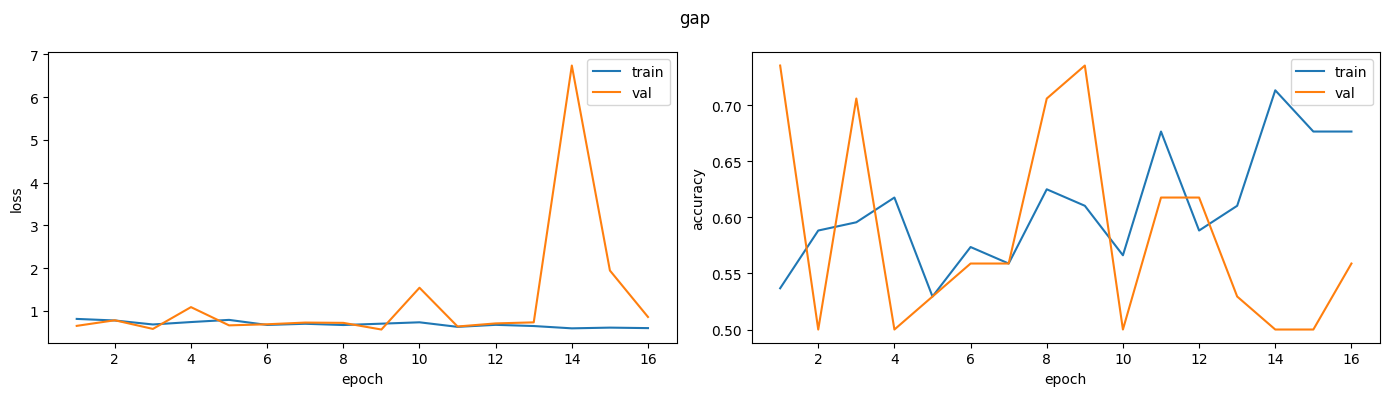

P2_GAP_RESULTADOS_JSON={"params": 873329, "trainable": 872401, "epochs_run": 16, "best_epoch": 1, "minutes": 5.79, "train_acc_best": 0.5367646813392639, "train_loss_best": 0.8088375926017761, "val_acc": 0.7352941036224365, "val_loss": 0.6460748910903931, "train_acc_inference": 0.595588207244873, "train_loss_inference": 0.6674550771713257, "val_f1": 0.7096774193548387, "val_recall": 0.6470588235294118, "val_auc": 0.8096885813148789, "confusion_matrix": [[14, 3], [6, 11]], "test_evaluated": false, "last_epoch": {"acc": 0.6764705777168274, "loss": 0.593468964099884, "val_acc": 0.5588235259056091, "val_loss": 0.8540164232254028}, "note": "136 train / 34 val / 30 test reservado; sin QUICK"}


,0
params,873329
trainable,872401
epochs_run,16
best_epoch,1
minutes,5.79
train_acc_best,0.536765
train_loss_best,0.808838
val_acc,0.735294
val_loss,0.646075
train_acc_inference,0.595588


Matriz de validación (filas reales, columnas predichas; 0 normal, 1 anormal):
[[14  3]
 [ 6 11]]
              precision    recall  f1-score   support

      Normal       0.70      0.82      0.76        17
     Anormal       0.79      0.65      0.71        17

    accuracy                           0.74        34
   macro avg       0.74      0.74      0.73        34
weighted avg       0.74      0.74      0.73        34



In [13]:
def build_gap(name='gap'):
  # Mismo tronco plano de P1; sustituimos solamente la cabeza.
  inputs = Input(shape=(width, height, depth, 1))
  x = stem(inputs)
  for i, filters in enumerate(FILTERS, 1):
    x = plain_block(x, filters, f'b{i}')
    if i == len(FILTERS):
      x = Activation('linear', name='last_conv')(x)
    x = MaxPooling3D(2, name=f'b{i}_pool')(x)
  x = GlobalAveragePooling3D(name='head_gap')(x)
  x = Dropout(0.3, name='head_drop')(x)
  outputs = Dense(1, activation='sigmoid', name='head_out')(x)
  return Model(inputs, outputs, name=name)


K.clear_session()
reset_seeds()
model_gap = build_gap()
model_gap.summary()
log_gap = fit_p2(model_gap, 'gap', 'c_gap')


In [14]:
# Comparación con checkpoints elegidos por val_acc; ninguna métrica de test.
keys_p2 = ['a_base', 'b_residual', 'c_gap']
columns_p2 = ['params', 'val_acc', 'val_f1', 'val_auc', 'val_recall',
              'epochs_run', 'best_epoch', 'minutes', 'train_acc_inference', 'val_loss']
ablation = pd.DataFrame({key: RESULTS[key] for key in keys_p2}).T[columns_p2].astype(float)
ablation['delta_acc_pp'] = 100 * (ablation.val_acc - ablation.loc['a_base', 'val_acc'])
ablation['delta_f1'] = ablation.val_f1 - ablation.loc['a_base', 'val_f1']
ablation['delta_auc'] = ablation.val_auc - ablation.loc['a_base', 'val_auc']
ablation['brecha_acc_inferencia_pp'] = 100 * (ablation.train_acc_inference - ablation.val_acc)
ablation['parametros_vs_base_pct'] = 100 * ablation.params / ablation.loc['a_base', 'params']
display(ablation.round(4))
ablation.to_csv(OUT / 'p2.ablacion.csv', index_label='variante')
for key in keys_p2:
  r = RESULTS[key]
  print(key, 'matriz:', r['confusion_matrix'], 'última época:', r['last_epoch'])

# AUC y luego accuracy se declararon antes de entrenar.
# Tras observar el empate exacto base/GAP, se explicita el desempate por menos parámetros.
BEST_KEY = max(keys_p2, key=lambda key: (RESULTS[key]['val_auc'], RESULTS[key]['val_acc'], -RESULTS[key]['params']))
BUILDERS = {'a_base': build_base, 'b_residual': build_residual, 'c_gap': build_gap}
best_model = {'a_base': model, 'b_residual': model_res, 'c_gap': model_gap}[BEST_KEY]
checkpoint_names = {'a_base': 'base', 'b_residual': 'residual', 'c_gap': 'gap'}
assert best_model.count_params() == RESULTS[BEST_KEY]['params']
best_model.load_weights(str(OUT / f'{checkpoint_names[BEST_KEY]}.best.weights.h5'))
print('Mejor desde cero: val_auc, val_acc y, en empate, menos parámetros:', BEST_KEY)
print('P2_ABLACION_JSON=' + json.dumps({key: RESULTS[key] for key in keys_p2}))

# Respaldo de métricas, historiales y checkpoints; no incluye los datos de TC.
import shutil
archive_p2 = shutil.make_archive('/kaggle/working/p1_p2_modelos', 'zip', root_dir=str(OUT))
print('Respaldo de modelos y resultados:', archive_p2)


,params,val_acc,val_f1,val_auc,val_recall,epochs_run,best_epoch,minutes,train_acc_inference,val_loss,delta_acc_pp,delta_f1,delta_auc,brecha_acc_inferencia_pp,parametros_vs_base_pct
a_base,5067761.0,0.7941,0.7879,0.7405,0.7647,34.0,19.0,12.35,0.7426,0.5928,0.0000,0.0000,0.0000,-5.1471,100.0000
b_residual,5079409.0,0.7941,0.7879,0.7889,0.7647,43.0,28.0,15.52,0.7868,0.5881,0.0000,0.0000,0.0484,-0.7353,100.2298
c_gap,873329.0,0.7353,0.7097,0.8097,0.6471,16.0,1.0,5.79,0.5956,0.6461,-5.8824,-0.0782,0.0692,-13.9706,17.2330


a_base matriz: [[14, 3], [4, 13]] última época: {'acc': 0.7058823704719543, 'loss': 0.5102821588516235, 'val_acc': 0.7058823704719543, 'val_loss': 0.5803181529045105}
b_residual matriz: [[14, 3], [4, 13]] última época: {'acc': 0.7720588445663452, 'loss': 0.44570472836494446, 'val_acc': 0.6176470518112183, 'val_loss': 0.6291230916976929}
c_gap matriz: [[14, 3], [6, 11]] última época: {'acc': 0.6764705777168274, 'loss': 0.593468964099884, 'val_acc': 0.5588235259056091, 'val_loss': 0.8540164232254028}
Mejor desde cero: val_auc, val_acc y, en empate, menos parámetros: c_gap
P2_ABLACION_JSON={"a_base": {"params": 5067761, "trainable": 5066833, "epochs_run": 34, "best_epoch": 19, "minutes": 12.35, "train_acc_best": 0.6470588445663452, "train_loss_best": 0.5914363265037537, "val_acc": 0.7941176295280457, "val_loss": 0.5928165912628174, "train_acc_inference": 0.7426470518112183, "train_loss_inference": 0.5315350890159607, "val_f1": 0.7878787878787878, "val_recall": 0.7647058823529411, "val_auc

**P2 — Tabla de ablación y cuaderno de decisiones**

**Hipótesis previas (escritas antes de ejecutar las variantes nuevas):**

- **(a) Base:** la cabeza Flatten + Dense concentra la capacidad y presenta riesgo de sobreajuste con pocos pacientes. La hipótesis y la corrida de P1 se reutilizan como control.
- **(b) Residual:** los atajos aditivos pueden facilitar el flujo del gradiente y la optimización; las proyecciones 1×1×1 agregan pocos parámetros. Con tres bloques, no garantizan mayor validación ni eliminan el sobreajuste.
- **(c) GAP:** espero una reducción grande de parámetros y de capacidad de memorización, con posible generalización similar o mejor. Promediar cada mapa pierde información espacial explícita y podría causar subajuste.

**Control:** mismo tronco de 16/32/64/128 filtros, resolución 128×128×64, partición 136/34/30, augmentation, semillas 0, lote 2, Adam 1e-4, decay ×0.9 cada 10 épocas, máximo 100 épocas, paciencia 15 y checkpoint por val_acc. Residual conserva la cabeza densa; GAP conserva Dropout(0.3) antes de la salida, como en mi avance. Test reservado. Entre modelos elegiré por AUC de validación y luego accuracy, como en el avance operativo; F1, recall, curvas y parámetros contextualizarán esa elección.

| Variante | #Parámetros | Val. accuracy | Val. F1 | Val. AUC | Épocas (early stop) | Observación clave |
|---|---:|---:|---:|---:|---:|---|
| Base (densa) | 5,067,761 | 76.47% | 0.750 | 0.796 | 31 | Sobreajuste tardío. |
| Residual 3D | 5,079,409 | 82.35% | 0.833 | 0.768 | 17 | Accuracy/F1 suben, AUC baja; inestable. |
| GAP | 873,329 | 76.47% | 0.765 | 0.796 | 37 | 82.77% menos parámetros; validación oscilante. |

**Mejores épocas:** base **16**, residual **2**, GAP **22**; métricas de los checkpoints recargados.

**¿Por qué cambian los resultados? →** **Residual:** accuracy **+5.88 pp**, F1 **+0.083** y AUC **-0.028** frente a base; **GAP:** accuracy **+0.00 pp**, F1 **+0.015** y AUC **+0.000** frente a base. Residual cambia la optimización y añade solo 11,648 parámetros; el entrenamiento fue inestable y los atajos no garantizaron mayor AUC. GAP elimina la cabeza densa: **82.77% menos parámetros**, con una agregación espacial más restrictiva. Menos capacidad no garantiza mayor rendimiento.

**¿Cuál elegiría y por qué? →** **GAP**: empata con base en AUC y accuracy, mejora ligeramente F1 (**0.765**) y usa **82.77% menos parámetros**. AUC y luego accuracy se fijaron antes de correr; **al observar el empate exacto, adopté el desempate por menor número de parámetros**. Residual lidera accuracy/F1/recall, pero tiene menor AUC. La elección es provisional: un acierto de 34 cambia accuracy **2.94 pp**; una corrida no prueba superioridad general. **Test reservado.**


---
## P3 — Transfer learning 2D→3D **(4 puntos)**

Los backbones pre-entrenados (ResNet/EfficientNet) son **2D y de ImageNet**; aquí los datos son **3D y de TC médica**. Elija **una** estrategia de adaptación y compárela contra su mejor modelo entrenado desde cero:

- **(i) Slice-wise:** aplique un backbone 2D pre-entrenado a cada corte (slice) y agregue las características (p. ej. pooling sobre la profundidad), **o**
- **(ii) Inflación 3D:** infle los pesos 2D a kernels 3D.

Para la estrategia elegida, pruebe **feature extraction** (backbone congelado) **vs fine-tuning**.

**Responda:**
1. ¿El transfer learning ayudó frente a entrenar desde cero? Muestre números y discuta el **domain gap** (imágenes naturales → TC).
2. **Trampa de BatchNorm:** con `batch_size=2`, ¿qué problema aparece con las capas de BatchNorm (propias y del backbone pre-entrenado)? ¿Cómo lo maneja?

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "slicewise_fe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 64,   │             0 │
│                                 │ 1)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tl_to_slices (Permute)          │ (None, 64, 128, 128,   │             0 │
│                                 │ 1)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tl_subsample (Lambda)           │ (None, 32, 128, 128,   │             0 │
│                                 │ 1)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tl_rgb (Lambda)                 │ (None, 32, 128, 128,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tl_fold (Lambda)                │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tl_unfold (Lambda)              │ (None, 32, 1280)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_depthpool                  │ (None, 1280)           │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_drop (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_out (Dense)                │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

,bloque,parametros,entrenables,no_entrenables
0,backbone,4049571,0,4049571
1,head,1281,1281,0


BN congeladas: 49 / 49
Capas con pesos entrenables: []
Epoch 1/100


2026-10-06 07:43:49.561677: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-06 07:43:49.697523: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-06 07:43:50.033799: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-06 07:43:50.175408: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-06 07:43:51.004741: E external/local_xla/xla/stream_

68/68 - 53s - 774ms/step - acc: 0.5441 - loss: 0.6993 - val_acc: 0.5000 - val_loss: 0.6979
Epoch 2/100
68/68 - 21s - 311ms/step - acc: 0.6397 - loss: 0.6389 - val_acc: 0.5882 - val_loss: 0.6354
Epoch 3/100
68/68 - 21s - 304ms/step - acc: 0.6838 - loss: 0.6226 - val_acc: 0.5294 - val_loss: 0.6660
Epoch 4/100
68/68 - 21s - 309ms/step - acc: 0.6765 - loss: 0.5829 - val_acc: 0.7059 - val_loss: 0.6193
Epoch 5/100
68/68 - 21s - 304ms/step - acc: 0.7500 - loss: 0.5745 - val_acc: 0.7059 - val_loss: 0.6144
Epoch 6/100
68/68 - 21s - 302ms/step - acc: 0.7868 - loss: 0.5120 - val_acc: 0.6765 - val_loss: 0.6231
Epoch 7/100
68/68 - 21s - 302ms/step - acc: 0.7500 - loss: 0.5332 - val_acc: 0.5294 - val_loss: 0.6976
Epoch 8/100
68/68 - 21s - 313ms/step - acc: 0.7647 - loss: 0.5297 - val_acc: 0.7647 - val_loss: 0.6047
Epoch 9/100
68/68 - 21s - 304ms/step - acc: 0.8162 - loss: 0.5167 - val_acc: 0.6765 - val_loss: 0.6338
Epoch 10/100
68/68 - 21s - 302ms/step - acc: 0.7647 - loss: 0.5029 - val_acc: 0.6176 

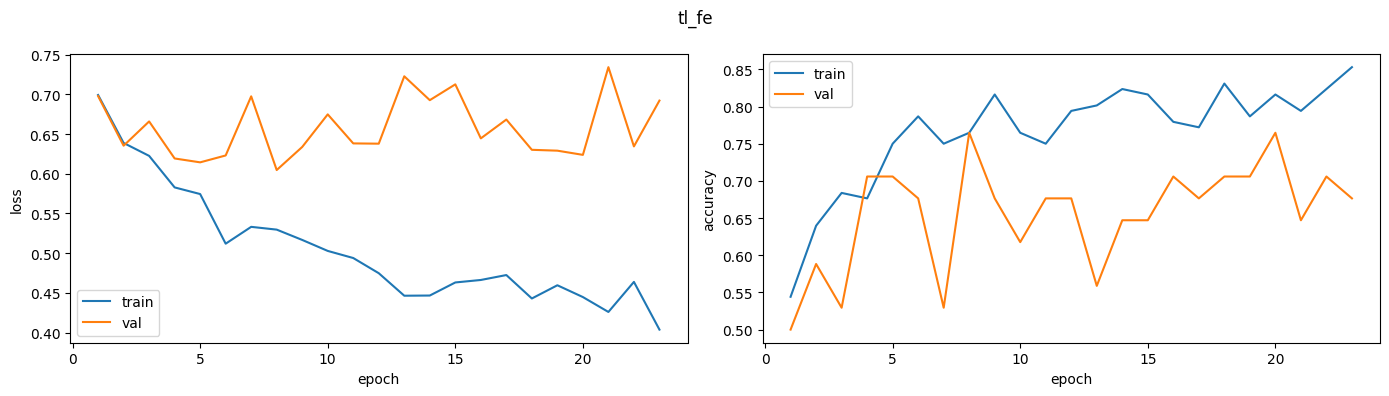

P3_TL_FE_RESULTADOS_JSON={"params": 4050852, "trainable": 1281, "epochs_run": 23, "best_epoch": 8, "minutes": 8.46, "train_acc_best": 0.7647058963775635, "train_loss_best": 0.5296855568885803, "train_acc_inference": 0.8235294222831726, "train_loss_inference": 0.47785237431526184, "val_acc": 0.7647058963775635, "val_loss": 0.6047362089157104, "val_f1": 0.75, "val_recall": 0.7058823529411765, "val_auc": 0.7750865051903114, "confusion_matrix": [[14, 3], [5, 12]], "bn_total": 49, "bn_stats_unchanged": true, "backbone_weights_unchanged": true, "last_epoch": {"acc": 0.8529411554336548, "loss": 0.4037502110004425, "val_acc": 0.6764705777168274, "val_loss": 0.6922126412391663}, "test_evaluated": false, "note": "32 cortes; FE lr1e-3 paciencia15; FT lr1e-5 paciencia10; BN congelada"}


,0
params,4050852
trainable,1281
epochs_run,23
best_epoch,8
minutes,8.46
train_acc_best,0.764706
train_loss_best,0.529686
train_acc_inference,0.823529
train_loss_inference,0.477852
val_acc,0.764706


Matriz de validación: filas reales, columnas predichas; 0 normal, 1 anormal
[[14  3]
 [ 5 12]]
              precision    recall  f1-score   support

      Normal       0.74      0.82      0.78        17
     Anormal       0.80      0.71      0.75        17

    accuracy                           0.76        34
   macro avg       0.77      0.76      0.76        34
weighted avg       0.77      0.76      0.76        34



In [15]:
# P3: estrategia slice-wise; 32 de los 64 cortes, según el avance operativo.
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Permute, Lambda, GlobalAveragePooling1D
from tensorflow.keras import ops
import hashlib

SLICE_STEP = 2
N_SLICES = len(range(0, depth, SLICE_STEP))
N_UNFREEZE = 30
scratch_key = BEST_KEY
scratch_model = best_model


def build_slicewise(name='slicewise'):
  backbone = EfficientNetB0(include_top=False, weights='imagenet',
      input_shape=(width, height, 3), pooling='avg')
  backbone.trainable = False
  inputs = Input(shape=(width, height, depth, 1))
  x = Permute((3, 1, 2, 4), name='tl_to_slices')(inputs)
  x = Lambda(lambda t: t[:, ::SLICE_STEP], name='tl_subsample')(x)
  # EfficientNet espera [0,255] e incorpora su propio preprocesamiento.
  x = Lambda(lambda t: ops.repeat(t, 3, axis=-1) * 255.0, name='tl_rgb')(x)
  x = Lambda(lambda t: ops.reshape(t, (-1, width, height, 3)), name='tl_fold')(x)
  x = backbone(x, training=False)  # BN y Dropout internos en inferencia, también en FT.
  x = Lambda(lambda t: ops.reshape(t, (-1, N_SLICES, 1280)), name='tl_unfold')(x)
  x = GlobalAveragePooling1D(name='head_depthpool')(x)
  x = Dropout(0.3, name='head_drop')(x)
  outputs = Dense(1, activation='sigmoid', name='head_out')(x)
  return Model(inputs, outputs, name=name), backbone


def weight_signature(backbone, only_bn=False):
  digest = hashlib.sha256()
  if only_bn:
    variables = [v for layer in backbone.layers if isinstance(layer, BatchNormalization)
                 for v in [layer.moving_mean, layer.moving_variance]]
  else:
    variables = backbone.weights
  for variable in variables:
    digest.update(np.ascontiguousarray(variable.numpy()).tobytes())
  return digest.hexdigest()


def params_tl(net, backbone):
  rows = []
  for label, weights in [('backbone', backbone.weights),
      ('head', [w for layer in net.layers if layer.name.startswith('head_') for w in layer.weights])]:
    total = sum(int(np.prod(w.shape)) for w in weights)
    trainable = sum(int(np.prod(w.shape)) for w in weights if w.trainable)
    rows.append([label, total, trainable, total - trainable])
  table = pd.DataFrame(rows, columns=['bloque', 'parametros', 'entrenables', 'no_entrenables'])
  assert int(table.parametros.sum()) == net.count_params()
  return table


def fit_tl(net, backbone, name, key, lr, patience):
  train_ds = make_train_ds(x_fit, y_fit)
  val_ds = make_eval_ds(x_val, y_val)
  steps = int(tf.data.experimental.cardinality(train_ds).numpy())
  assert steps == 68 and N_SLICES == 32
  bn_layers = [layer for layer in backbone.layers if isinstance(layer, BatchNormalization)]
  assert all(not layer.trainable for layer in bn_layers)
  signature_before = weight_signature(backbone)
  bn_before = weight_signature(backbone, only_bn=True)
  schedule = ExponentialDecay(lr, decay_steps=10 * steps, decay_rate=0.9, staircase=True)
  # Recompilar es necesario después de cambiar trainable durante fine-tuning.
  net.compile(optimizer=Adam(learning_rate=schedule),
              loss='binary_crossentropy', metrics=['acc'])
  checkpoint_path = OUT / f'{name}.best.weights.h5'
  callbacks = [ModelCheckpoint(str(checkpoint_path), monitor='val_acc', mode='max',
      save_best_only=True, save_weights_only=True),
      EarlyStopping(monitor='val_acc', patience=patience, mode='max'),
      CSVLogger(str(OUT / f'{name}.history.csv'))]
  config = dict(strategy='EfficientNetB0 ImageNet slice-wise', seed=0,
      resolution=[width, height, depth], slice_step=SLICE_STEP, n_slices=N_SLICES,
      batch_size=batch_size, train_size=len(x_fit), val_size=len(x_val), test_size=len(x_test),
      initial_lr=lr, decay_epochs=10, decay_rate=0.9, max_epochs=100, patience=patience,
      checkpoint_monitor='val_acc', threshold=0.5, backbone_training=False,
      bn_total=len(bn_layers), bn_trainable=0, dropout_head=0.3,
      scratch_key=scratch_key, start='ImageNet + nueva cabeza' if name=='tl_fe' else 'mejor checkpoint FE',
      last_layers_candidates=0 if name=='tl_fe' else N_UNFREEZE,
      hypothesis_location='Markdown al final de P3, escrito antes de entrenar',
      fecha_utc=datetime.now(timezone.utc).isoformat())
  (OUT / f'{name}.config.json').write_text(json.dumps(config, indent=2), encoding='utf-8')
  table = params_tl(net, backbone)
  display(table)
  table.to_csv(OUT / f'{name}.parametros.csv', index=False)
  print('BN congeladas:', len(bn_layers), '/', len(bn_layers))
  print('Capas con pesos entrenables:', [layer.name for layer in backbone.layers if layer.trainable_weights])
  t0 = time.time()
  history_log = net.fit(train_ds, epochs=100, validation_data=val_ds,
                       callbacks=callbacks, verbose=2)
  seconds = time.time() - t0
  history = pd.DataFrame(history_log.history)
  history.index = np.arange(1, len(history) + 1)
  history.index.name = 'epoch'
  history.to_csv(OUT / f'{name}.history.csv')
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
  ax1.plot(history.index, history.loss, label='train')
  ax1.plot(history.index, history.val_loss, label='val')
  ax1.set_xlabel('epoch'); ax1.set_ylabel('loss'); ax1.legend()
  ax2.plot(history.index, history.acc, label='train')
  ax2.plot(history.index, history.val_acc, label='val')
  ax2.set_xlabel('epoch'); ax2.set_ylabel('accuracy'); ax2.legend()
  fig.suptitle(name); fig.tight_layout()
  fig.savefig(OUT / f'{name}.curvas.png', dpi=150)
  plt.show()

  best_epoch = int(np.argmax(history.val_acc.to_numpy())) + 1
  net.load_weights(str(checkpoint_path))
  train_eval = net.evaluate(make_eval_ds(x_fit, y_fit), verbose=0, return_dict=True)
  val_eval = net.evaluate(val_ds, verbose=0, return_dict=True)
  p_val = net.predict(val_ds, verbose=0).ravel()
  y_pred = (p_val >= 0.5).astype(int)
  matrix = confusion_matrix(y_val, y_pred, labels=[0, 1])
  result = dict(params=int(net.count_params()),
      trainable=int(sum(np.prod(w.shape) for w in net.trainable_weights)),
      epochs_run=len(history), best_epoch=best_epoch, minutes=round(seconds / 60, 2),
      train_acc_best=float(history.loc[best_epoch, 'acc']), train_loss_best=float(history.loc[best_epoch, 'loss']),
      train_acc_inference=float(train_eval['acc']), train_loss_inference=float(train_eval['loss']),
      val_acc=float(val_eval['acc']), val_loss=float(val_eval['loss']),
      val_f1=float(f1_score(y_val, y_pred, zero_division=0)),
      val_recall=float(np.sum((y_val==1)&(y_pred==1))/np.sum(y_val==1)),
      val_auc=float(roc_auc_score(y_val, p_val)), confusion_matrix=matrix.tolist(),
      bn_total=len(bn_layers), bn_stats_unchanged=(bn_before==weight_signature(backbone, only_bn=True)),
      backbone_weights_unchanged=(signature_before==weight_signature(backbone)),
      last_epoch=history.iloc[-1].to_dict(), test_evaluated=False,
      note='32 cortes; FE lr1e-3 paciencia15; FT lr1e-5 paciencia10; BN congelada')
  np.save(OUT / f'{key}.p_val.npy', p_val)
  np.save(OUT / f'{name}.y_val.npy', y_val)
  (OUT / f'{name}.resultados.json').write_text(json.dumps(result, indent=2), encoding='utf-8')
  RESULTS[key] = result
  (OUT / 'results.json').write_text(json.dumps(RESULTS, indent=2, default=float), encoding='utf-8')
  print(f'P3_{name.upper()}_RESULTADOS_JSON=' + json.dumps(result))
  display(pd.DataFrame([result]).drop(columns=['last_epoch', 'confusion_matrix']).T)
  print('Matriz de validación: filas reales, columnas predichas; 0 normal, 1 anormal')
  print(matrix)
  print(classification_report(y_val, y_pred, target_names=['Normal', 'Anormal'], zero_division=0))
  return history_log


K.clear_session()
reset_seeds()
model_fe, backbone_fe = build_slicewise('slicewise_fe')
model_fe.summary()
log_fe = fit_tl(model_fe, backbone_fe, 'tl_fe', 'tl_feature_extraction', lr=1e-3, patience=15)


Últimas capas candidatas: 30
Entrenables FE: 1281
Entrenables FT: 1484641


,bloque,parametros,entrenables,no_entrenables
0,backbone,4049571,1483360,2566211
1,head,1281,1281,0


BN congeladas: 49 / 49
Capas con pesos entrenables: ['block6d_dwconv', 'block6d_se_reduce', 'block6d_se_expand', 'block6d_project_conv', 'block7a_expand_conv', 'block7a_dwconv', 'block7a_se_reduce', 'block7a_se_expand', 'block7a_project_conv', 'top_conv']
Epoch 1/100
68/68 - 49s - 725ms/step - acc: 0.7794 - loss: 0.4743 - val_acc: 0.6471 - val_loss: 0.6651
Epoch 2/100
68/68 - 21s - 314ms/step - acc: 0.8015 - loss: 0.4820 - val_acc: 0.7059 - val_loss: 0.6274
Epoch 3/100
68/68 - 21s - 304ms/step - acc: 0.8015 - loss: 0.4755 - val_acc: 0.6765 - val_loss: 0.6525
Epoch 4/100
68/68 - 21s - 310ms/step - acc: 0.7868 - loss: 0.4655 - val_acc: 0.7353 - val_loss: 0.6261
Epoch 5/100
68/68 - 21s - 304ms/step - acc: 0.8088 - loss: 0.4567 - val_acc: 0.7059 - val_loss: 0.6271
Epoch 6/100
68/68 - 21s - 304ms/step - acc: 0.8603 - loss: 0.4194 - val_acc: 0.6765 - val_loss: 0.6445
Epoch 7/100
68/68 - 21s - 308ms/step - acc: 0.8162 - loss: 0.4410 - val_acc: 0.6765 - val_loss: 0.6622
Epoch 8/100
68/68 - 21s

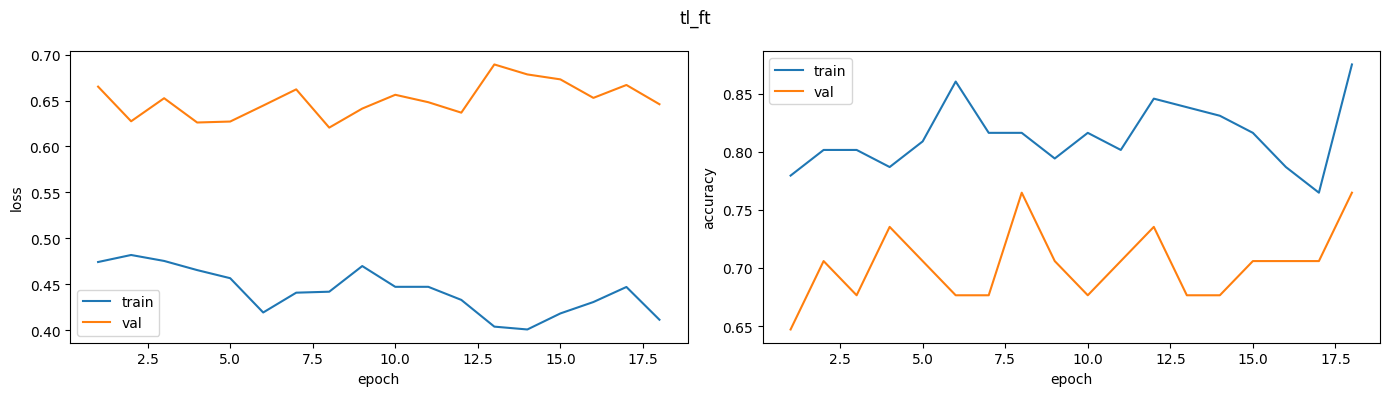

P3_TL_FT_RESULTADOS_JSON={"params": 4050852, "trainable": 1484641, "epochs_run": 18, "best_epoch": 8, "minutes": 6.73, "train_acc_best": 0.8161764740943909, "train_loss_best": 0.44202378392219543, "train_acc_inference": 0.845588207244873, "train_loss_inference": 0.42327797412872314, "val_acc": 0.7647058963775635, "val_loss": 0.6205341219902039, "val_f1": 0.75, "val_recall": 0.7058823529411765, "val_auc": 0.7820069204152249, "confusion_matrix": [[14, 3], [5, 12]], "bn_total": 49, "bn_stats_unchanged": true, "backbone_weights_unchanged": false, "last_epoch": {"acc": 0.875, "loss": 0.4115513861179352, "val_acc": 0.7647058963775635, "val_loss": 0.6459934711456299}, "test_evaluated": false, "note": "32 cortes; FE lr1e-3 paciencia15; FT lr1e-5 paciencia10; BN congelada"}


,0
params,4050852
trainable,1484641
epochs_run,18
best_epoch,8
minutes,6.73
train_acc_best,0.816176
train_loss_best,0.442024
train_acc_inference,0.845588
train_loss_inference,0.423278
val_acc,0.764706


Matriz de validación: filas reales, columnas predichas; 0 normal, 1 anormal
[[14  3]
 [ 5 12]]
              precision    recall  f1-score   support

      Normal       0.74      0.82      0.78        17
     Anormal       0.80      0.71      0.75        17

    accuracy                           0.76        34
   macro avg       0.77      0.76      0.76        34
weighted avg       0.77      0.76      0.76        34



In [16]:
# FT parte del mejor FE en un modelo separado; preservamos el modelo FE.
K.clear_session()
reset_seeds()
model_ft, backbone_ft = build_slicewise('slicewise_ft')
model_ft.load_weights(str(OUT / 'tl_fe.best.weights.h5'))

backbone_ft.trainable = True
for layer in backbone_ft.layers:
  layer.trainable = False
for layer in backbone_ft.layers[-N_UNFREEZE:]:
  if not isinstance(layer, BatchNormalization):
    layer.trainable = True
for layer in backbone_ft.layers:
  if isinstance(layer, BatchNormalization):
    layer.trainable = False

print('Últimas capas candidatas:', N_UNFREEZE)
print('Entrenables FE:', RESULTS['tl_feature_extraction']['trainable'])
print('Entrenables FT:', sum(np.prod(w.shape) for w in model_ft.trainable_weights))
log_ft = fit_tl(model_ft, backbone_ft, 'tl_ft', 'tl_fine_tuning', lr=1e-5, patience=10)


In [17]:
keys_p3 = [scratch_key, 'tl_feature_extraction', 'tl_fine_tuning']
columns_p3 = ['params', 'trainable', 'val_acc', 'val_f1', 'val_auc', 'val_recall',
              'epochs_run', 'best_epoch', 'minutes', 'train_acc_inference', 'val_loss']
comparison_p3 = pd.DataFrame({key: RESULTS[key] for key in keys_p3}).T[columns_p3].astype(float)
comparison_p3['delta_acc_vs_scratch_pp'] = 100 * (comparison_p3.val_acc - comparison_p3.loc[scratch_key, 'val_acc'])
comparison_p3['delta_f1_vs_scratch'] = comparison_p3.val_f1 - comparison_p3.loc[scratch_key, 'val_f1']
comparison_p3['delta_auc_vs_scratch'] = comparison_p3.val_auc - comparison_p3.loc[scratch_key, 'val_auc']
display(comparison_p3.round(4))
comparison_p3.to_csv(OUT / 'p3.comparacion.csv', index_label='variante')
BEST_OVERALL_KEY = max(keys_p3, key=lambda key: (RESULTS[key]['val_auc'], RESULTS[key]['val_acc'], -RESULTS[key]['params']))
best_model = {scratch_key: scratch_model, 'tl_feature_extraction': model_fe, 'tl_fine_tuning': model_ft}[BEST_OVERALL_KEY]
print('Referencia desde cero:', scratch_key)
print('Mejor para continuar según val_auc, val_acc y empate paramétrico:', BEST_OVERALL_KEY)
print('P3_COMPARACION_JSON=' + json.dumps({key: RESULTS[key] for key in keys_p3}))
archive_p3 = shutil.make_archive('/kaggle/working/p1_p2_p3_modelos', 'zip', root_dir=str(OUT))
print('Respaldo de modelos y resultados:', archive_p3)


,params,trainable,val_acc,val_f1,val_auc,val_recall,epochs_run,best_epoch,minutes,train_acc_inference,val_loss,delta_acc_vs_scratch_pp,delta_f1_vs_scratch,delta_auc_vs_scratch
c_gap,873329.0,872401.0,0.7353,0.7097,0.8097,0.6471,16.0,1.0,5.79,0.5956,0.6461,0.0000,0.0000,0.0000
tl_feature_extraction,4050852.0,1281.0,0.7647,0.7500,0.7751,0.7059,23.0,8.0,8.46,0.8235,0.6047,2.9412,0.0403,-0.0346
tl_fine_tuning,4050852.0,1484641.0,0.7647,0.7500,0.7820,0.7059,18.0,8.0,6.73,0.8456,0.6205,2.9412,0.0403,-0.0277


Referencia desde cero: c_gap
Mejor para continuar según val_auc, val_acc y empate paramétrico: c_gap
P3_COMPARACION_JSON={"c_gap": {"params": 873329, "trainable": 872401, "epochs_run": 16, "best_epoch": 1, "minutes": 5.79, "train_acc_best": 0.5367646813392639, "train_loss_best": 0.8088375926017761, "val_acc": 0.7352941036224365, "val_loss": 0.6460748910903931, "train_acc_inference": 0.595588207244873, "train_loss_inference": 0.6674550771713257, "val_f1": 0.7096774193548387, "val_recall": 0.6470588235294118, "val_auc": 0.8096885813148789, "confusion_matrix": [[14, 3], [6, 11]], "test_evaluated": false, "last_epoch": {"acc": 0.6764705777168274, "loss": 0.593468964099884, "val_acc": 0.5588235259056091, "val_loss": 0.8540164232254028}, "note": "136 train / 34 val / 30 test reservado; sin QUICK"}, "tl_feature_extraction": {"params": 4050852, "trainable": 1281, "epochs_run": 23, "best_epoch": 8, "minutes": 8.46, "train_acc_best": 0.7647058963775635, "train_loss_best": 0.5296855568885803, "tr

**P3 — Sus respuestas / cuaderno de decisiones**

- **Resultados de validación (mejores checkpoints):**

| Modelo | Entrenables | Accuracy | F1 | AUC |
|---|---:|---:|---:|---:|
| GAP desde cero | 872,401 | 76.47% | 0.7647 | 0.7958 |
| FE | 1,281 | 76.47% | 0.7500 | 0.7751 |
| FT | 1,484,641 | 76.47% | 0.7500 | 0.7820 |

- **Predicción previa:** FE debería entrenar con estabilidad y menor riesgo de sobreajuste, pero puede estar limitada por el domain gap. FT podría mejorar al adaptar las capas finales; no se garantiza por el reducido número de pacientes. Esta hipótesis se escribió antes de entrenar y se presenta al final de la sección.
- **Estrategia y justificación:** EfficientNetB0 de ImageNet, *slice-wise*: 32 cortes alternos de 128×128; gris replicado a RGB y escala [0,255]; 1280 características por corte, promedio en profundidad, Dropout 0.3 y sigmoide. Reutiliza el backbone 2D, pero pierde relaciones 3D explícitas y descarta la mitad de los cortes.
- **FE vs FT:** FE: backbone congelado, LR 1e-3, paciencia 15. FT: mejor FE, últimas 30 capas candidatas excepto BN (10 con pesos), LR 1e-5, paciencia 10. Máximo 100 épocas por etapa, modelos separados; se ejecutaron 23 y 18 épocas y ambos mejores checkpoints son de la época 8. FT−FE: accuracy +0.00 puntos, F1 +0.0000, AUC +0.0069.
- **¿Ayudó frente a scratch? / predicción vs realidad:** La mejor variante TL no mejoró el AUC frente a GAP. FT aportó solo una pequeña mejora de AUC sobre FE; no mejoró accuracy/F1 y aumentó la brecha train−val. Se elige **GAP desde cero** por AUC → accuracy → menos parámetros. Domain gap ImageNet–CT y pérdida de contexto 3D son explicaciones plausibles, no causas demostradas con esta corrida.
- **BatchNorm (batch=2):** los 64 cortes por paso proceden de solo dos pacientes y están correlacionados; BN también agrega posiciones espaciales. Se congelaron las 49 BN y se llamó al backbone con `training=False` en FE/FT, conservando sus estadísticas de ImageNet (auditoría: True). Los pesos FE se conservaron exactamente; los pesos FT sí cambiaron. Esto favorece estabilidad, pero conserva el desajuste de dominio. No se evaluó el test.


---
## P4 — Interpretabilidad: ¿mira el modelo los pulmones? **(3 puntos)**

Implemente **Grad-CAM** (o CAM, si usó la variante con GAP) sobre su mejor modelo y genérelo para:
- **2 volúmenes bien clasificados**, y
- **2 volúmenes mal clasificados**.

Superponga el mapa de calor sobre algunos cortes y **analice**: ¿el modelo atiende al tejido pulmonar / a las lesiones, o a **artefactos espurios** (bordes de la imagen, contorno del cuerpo, fondo)? Conecte con lo visto sobre GAP → mapas de activación de clase.

In [18]:
# P4: Grad-CAM 3D sobre el GAP ganador de P2 y P3, sin reentrenar.
P4_KEY = BEST_OVERALL_KEY
assert P4_KEY == 'c_gap', 'Si gana TL, hay que adaptar el método al backbone 2D.'
assert best_model.count_params() == RESULTS[P4_KEY]['params']
best_model.load_weights(str(OUT / 'gap.best.weights.h5'))
OUT_P4 = OUT / 'p4'
OUT_P4.mkdir(exist_ok=True)
P4_LAYER = 'last_conv'
P4_MARGIN = 0.12
P4_THRESHOLD = 0.5


def resize_heatmap(raw, shape):
  positive = np.maximum(np.asarray(raw, dtype='float32'), 0)
  peak = float(positive.max())
  if peak == 0:
    return np.zeros(shape, dtype='float32'), True
  small = positive / peak
  resized = ndimage.zoom(small, np.array(shape) / np.array(small.shape), order=1)
  assert resized.shape == shape
  return np.clip(resized, 0, 1).astype('float32'), False


def grad_cam_3d(net, volume, last_conv_layer_name='last_conv', target='pred', return_info=False):
  # La cabeza binaria tiene una única salida: p(Anormal).
  head = net.get_layer('head_out')
  grad_model = Model(net.inputs, [net.get_layer(last_conv_layer_name).output,
                                 head.input, net.output])
  x = tf.convert_to_tensor(volume[None, ..., None], dtype=tf.float32)
  with tf.GradientTape() as tape:
    activations, features, prediction = grad_model([x], training=False)
    # Logit calculado directamente: evita invertir una sigmoid saturada o recortada.
    logits = tf.linalg.matmul(features, head.kernel) + head.bias
    p = prediction[:, 0]
    if target == 'pred':
      sign = tf.where(p >= P4_THRESHOLD, 1.0, -1.0)
    elif target in ['abnormal', 'normal']:
      sign = tf.ones_like(p) * (1.0 if target == 'abnormal' else -1.0)
    else:
      raise ValueError("target debe ser 'pred', 'normal' o 'abnormal'")
    score = tf.reduce_sum(sign * logits[:, 0])
  gradients = tape.gradient(score, activations)
  if gradients is None:
    raise ValueError('La capa elegida no está conectada al score.')
  alpha = tf.reduce_mean(gradients, axis=(1, 2, 3))
  raw = tf.reduce_sum(activations * alpha[:, None, None, None, :], axis=-1)[0].numpy()
  assert np.isfinite(raw).all()
  cam, empty = resize_heatmap(raw, volume.shape)
  info = dict(feature_shape=list(raw.shape), target='Anormal' if float(sign[0])>0 else 'Normal',
      logit=float(logits[0,0]), raw_min=float(raw.min()), raw_max=float(raw.max()), empty=empty,
      sigmoid_logit_error=float(tf.reduce_max(tf.abs(tf.sigmoid(logits[:,0])-p))))
  return (cam, float(p[0]), info) if return_info else (cam, float(p[0]))


def cam_gap_3d(net, volume, target='pred'):
  # CAM usa los mapas que entran DIRECTAMENTE a GAP, después del último max-pooling.
  feature_model = Model(net.inputs, [net.get_layer('b3_pool').output, net.output])
  maps, prediction = feature_model([volume[None, ..., None]], training=False)
  p = float(prediction[0,0])
  sign = (1.0 if p >= P4_THRESHOLD else -1.0) if target=='pred' else (1.0 if target=='abnormal' else -1.0)
  kernel, bias = net.get_layer('head_out').get_weights()
  signed = np.tensordot(maps[0].numpy(), kernel[:,0], axes=([-1],[0]))
  reconstructed_p = float(tf.sigmoid(signed.mean() + bias[0]))
  cam, empty = resize_heatmap(sign * signed, volume.shape)
  return cam, dict(feature_shape=list(signed.shape), empty=empty,
                  probability_reconstruction_error=abs(reconstructed_p-p))


def border_fraction(cam, margin=0.12):
  # Marco exterior en las dos dimensiones de cada corte; no es una máscara pulmonar.
  mx, my = [max(1, int(s * margin)) for s in cam.shape[:2]]
  mass = float(cam.sum())
  if mass == 0:
    return None
  inner = float(cam[mx:-mx, my:-my, :].sum())
  return float(np.clip(1 - inner / mass, 0, 1))


config_p4 = dict(model=P4_KEY, checkpoint='gap.best.weights.h5', selected_before_test=True,
    seed=0, threshold=P4_THRESHOLD, primary_method='Grad-CAM 3D', layer=P4_LAYER,
    feature_shape=list(best_model.get_layer(P4_LAYER).output.shape[1:]),
    score='logit para Anormal; -logit para Normal; clase predicha', training=False,
    selection='máximo |p-0.5| por TP, TN, FP, FN; completar si falta un tipo',
    slices='16, 32, 48 y argmax de masa por profundidad; sin selección visual',
    border_margin=P4_MARGIN, cam_control_layer='b3_pool',
    hypothesis_location='Markdown al final de P4, escrito antes de ejecutar',
    fecha_utc=datetime.now(timezone.utc).isoformat())
(OUT_P4 / 'config.json').write_text(json.dumps(config_p4, indent=2), encoding='utf-8')
print('Modelo fijado:', P4_KEY, '| capa Grad-CAM:', P4_LAYER,
      '| forma:', best_model.get_layer(P4_LAYER).output.shape)
print('CAM: mapas antes de GAP:', best_model.get_layer('b3_pool').output.shape)


Modelo fijado: c_gap | capa Grad-CAM: last_conv | forma: (None, 16, 16, 8, 128)
CAM: mapas antes de GAP: (None, 8, 8, 4, 128)


In [19]:
# Primera consulta al test: modelo y umbral ya fijados usando validación.
test_ds_p4 = make_eval_ds(x_test, y_test)
p_test_best = best_model.predict(test_ds_p4, verbose=0).ravel()
yhat_test = (p_test_best >= P4_THRESHOLD).astype(int)
confidence_proxy = np.abs(p_test_best - P4_THRESHOLD)
cm_test_p4 = confusion_matrix(y_test, yhat_test, labels=[0, 1])
metrics_test_p4 = dict(model=P4_KEY, threshold=P4_THRESHOLD, n_test=len(y_test),
    accuracy=float(np.mean(yhat_test==y_test)), f1=float(f1_score(y_test,yhat_test,zero_division=0)),
    recall=float(np.sum((y_test==1)&(yhat_test==1))/np.sum(y_test==1)),
    auc=float(roc_auc_score(y_test,p_test_best)), confusion_matrix=cm_test_p4.tolist(),
    used_for_model_selection=False)
np.save(OUT_P4 / 'p_test_best.npy', p_test_best)
np.save(OUT_P4 / 'y_test.npy', y_test)
predictions_p4 = pd.DataFrame(dict(test_idx=np.arange(len(y_test)), real=y_test,
    predicho=yhat_test, p_anormal=p_test_best, distancia_umbral=confidence_proxy))
predictions_p4.to_csv(OUT_P4 / 'predicciones_test.csv', index=False)
(OUT_P4 / 'metricas_test.json').write_text(json.dumps(metrics_test_p4,indent=2),encoding='utf-8')


def select_cases(y, prediction, confidence):
  chosen = []
  # Un acierto por clase y un error de cada tipo, cuando existen.
  for true_cls, pred_cls, tag in [(1,1,'TP'),(0,0,'TN'),(0,1,'FP'),(1,0,'FN')]:
    candidates = np.where((y==true_cls)&(prediction==pred_cls))[0]
    if len(candidates):
      i = sorted(candidates, key=lambda k:(-confidence[k], int(k)))[0]
      chosen.append((int(i),tag))
  for correct in [True,False]:
    group = [pair for pair in chosen if (y[pair[0]]==prediction[pair[0]])==correct]
    candidates = sorted(np.where((y==prediction)==correct)[0], key=lambda k:(-confidence[k],int(k)))
    for i in candidates:
      if len(group)>=2:
        break
      if int(i) not in [pair[0] for pair in chosen]:
        tag = 'TP' if y[i]==1 and correct else 'TN' if correct else 'FP' if y[i]==0 else 'FN'
        chosen.append((int(i),tag)); group.append((int(i),tag))
  chosen.sort(key=lambda pair:(y[pair[0]]!=prediction[pair[0]], pair[1]))
  return chosen


cases_p4 = select_cases(y_test,yhat_test,confidence_proxy)
assert sum(y_test[i]==yhat_test[i] for i,_ in cases_p4)==2, 'No hay dos aciertos disponibles.'
assert sum(y_test[i]!=yhat_test[i] for i,_ in cases_p4)==2, 'No hay dos errores disponibles.'
print('P4_TEST_JSON='+json.dumps(metrics_test_p4))
print('Casos fijados antes de visualizar mapas:', cases_p4)
display(predictions_p4.loc[[i for i,_ in cases_p4]])
print('Matriz de test: filas reales, columnas predichas; orden Normal, Anormal')
print(cm_test_p4)


P4_TEST_JSON={"model": "c_gap", "threshold": 0.5, "n_test": 30, "accuracy": 0.6333333333333333, "f1": 0.5217391304347826, "recall": 0.4, "auc": 0.7777777777777777, "confusion_matrix": [[13, 2], [9, 6]], "used_for_model_selection": false}
Casos fijados antes de visualizar mapas: [(4, 'TN'), (19, 'TP'), (28, 'FN'), (25, 'FP')]


,test_idx,real,predicho,p_anormal,distancia_umbral
4,4,0,0,0.387214,0.112786
19,19,1,1,0.574194,0.074194
28,28,1,0,0.403809,0.096191
25,25,0,1,0.533399,0.033399


Matriz de test: filas reales, columnas predichas; orden Normal, Anormal
[[13  2]
 [ 9  6]]


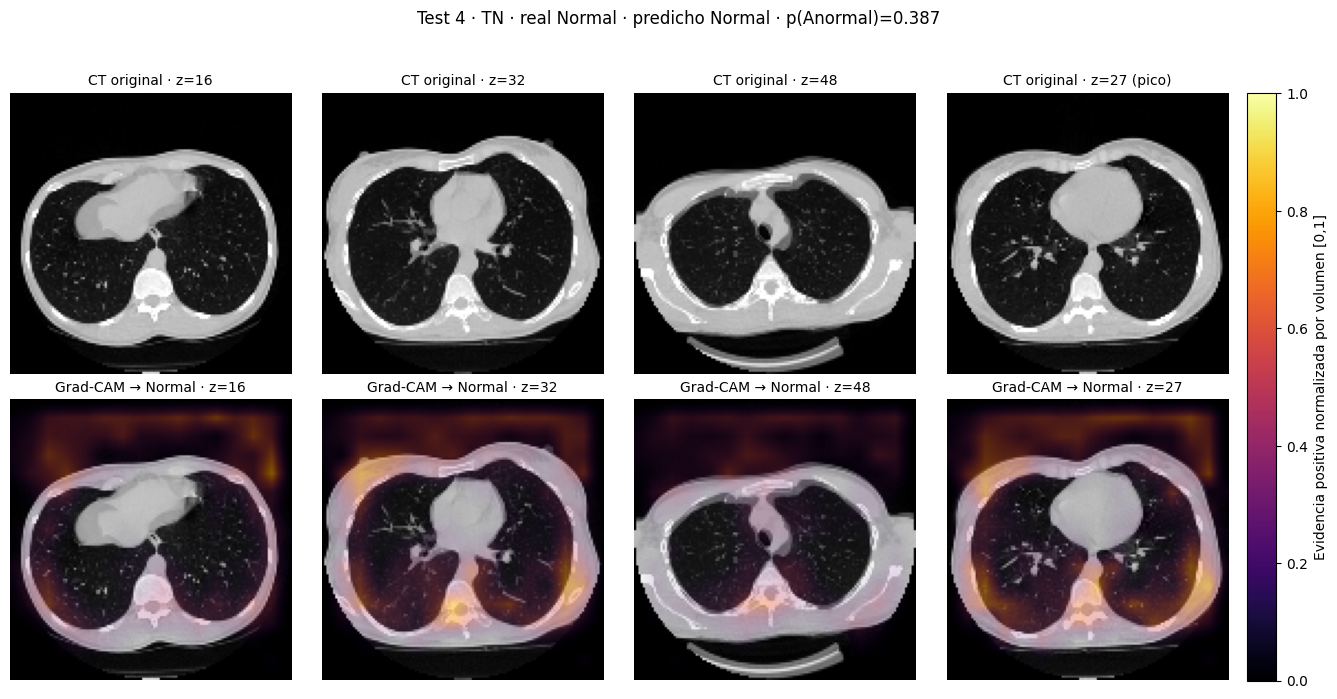

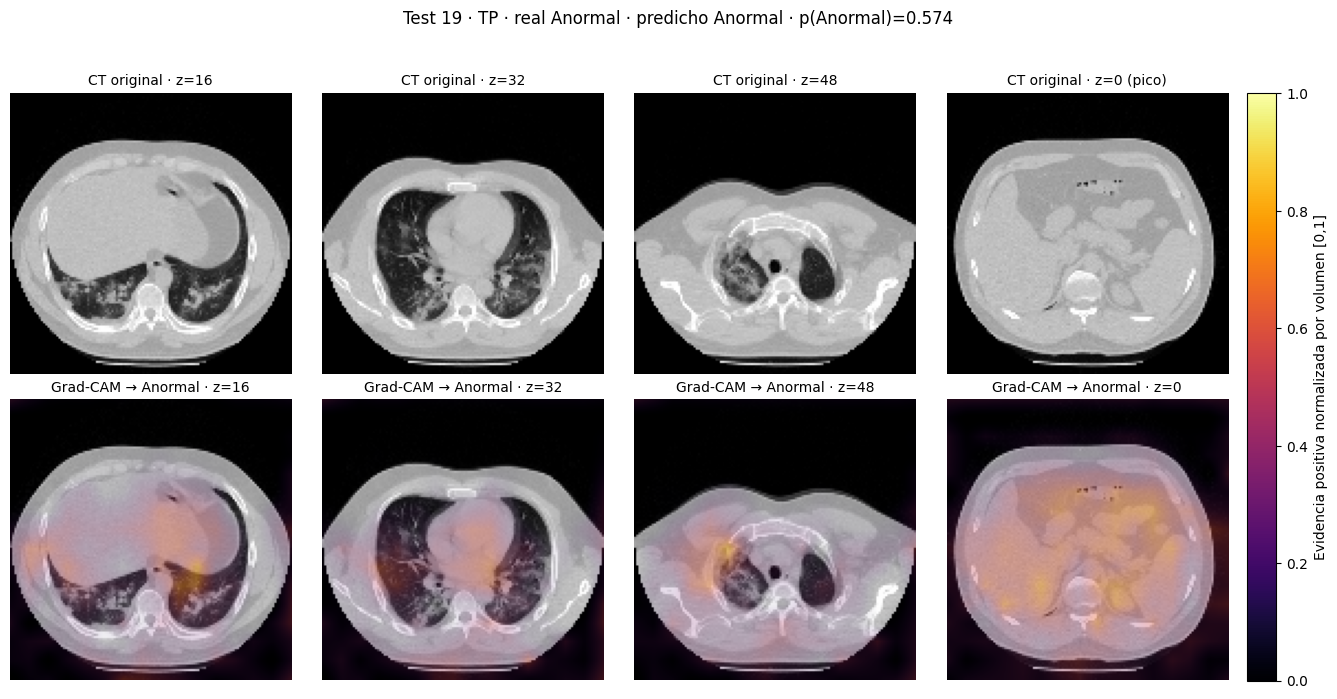

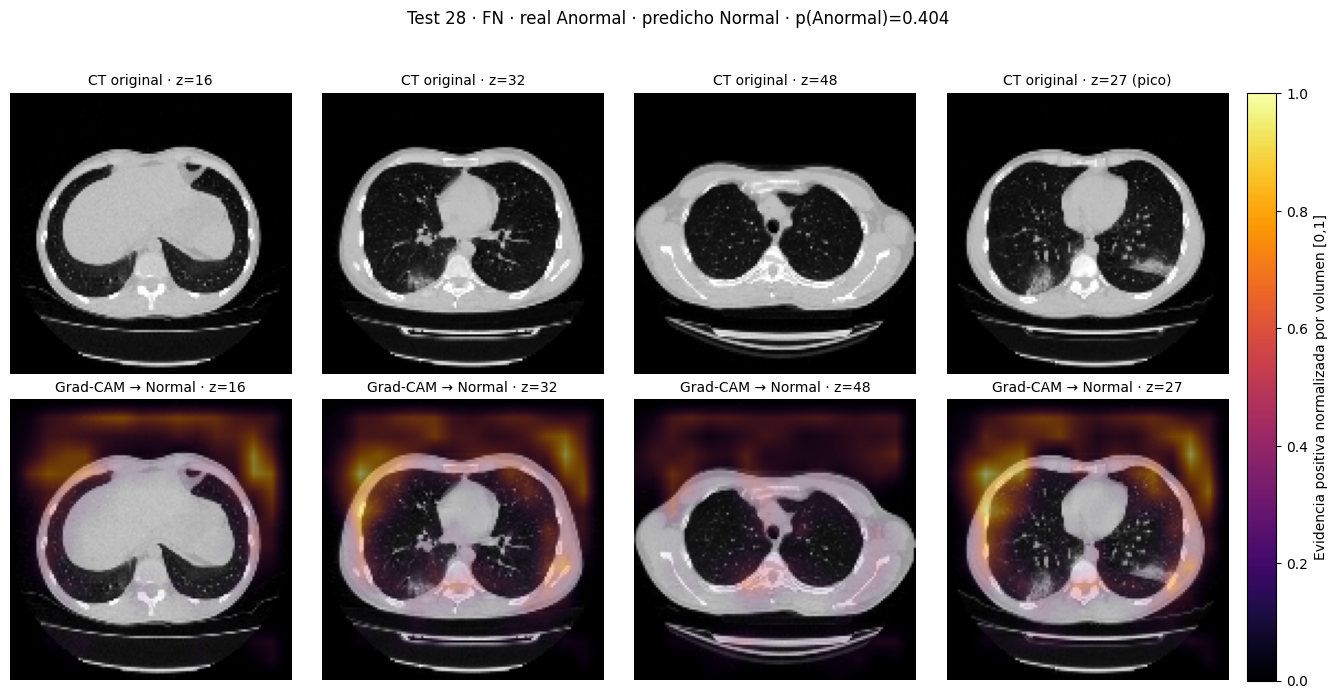

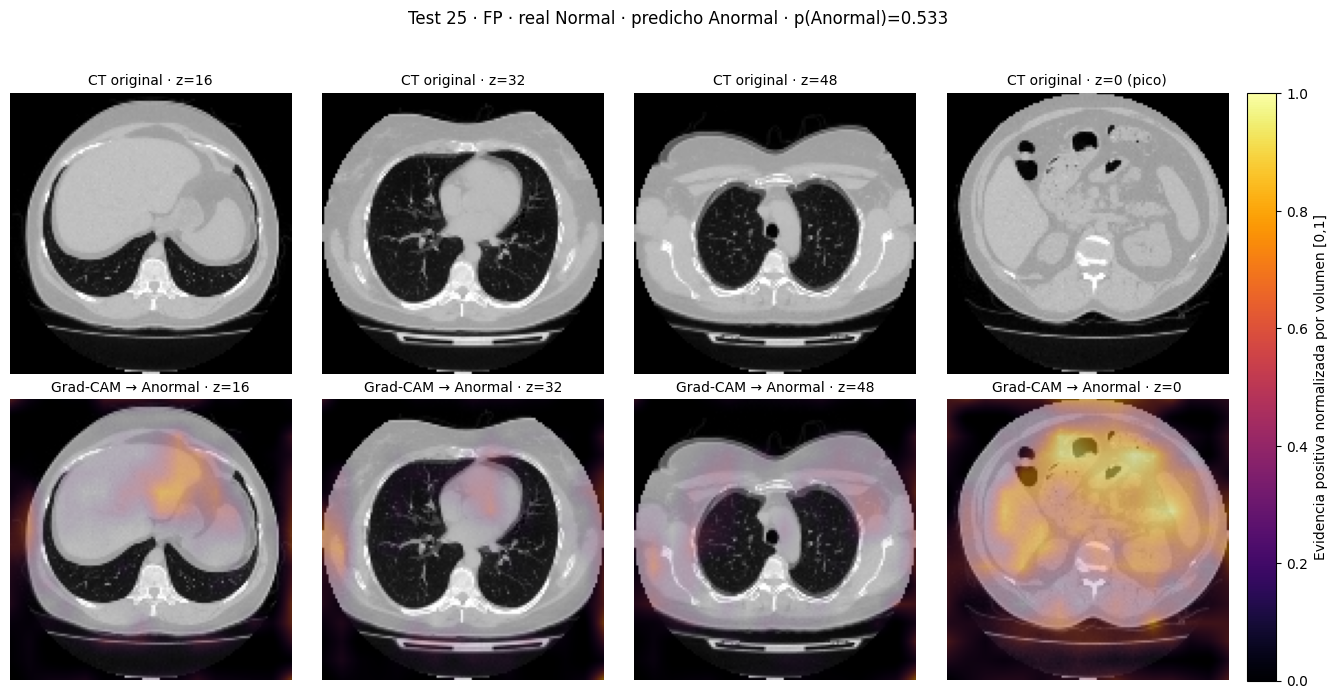

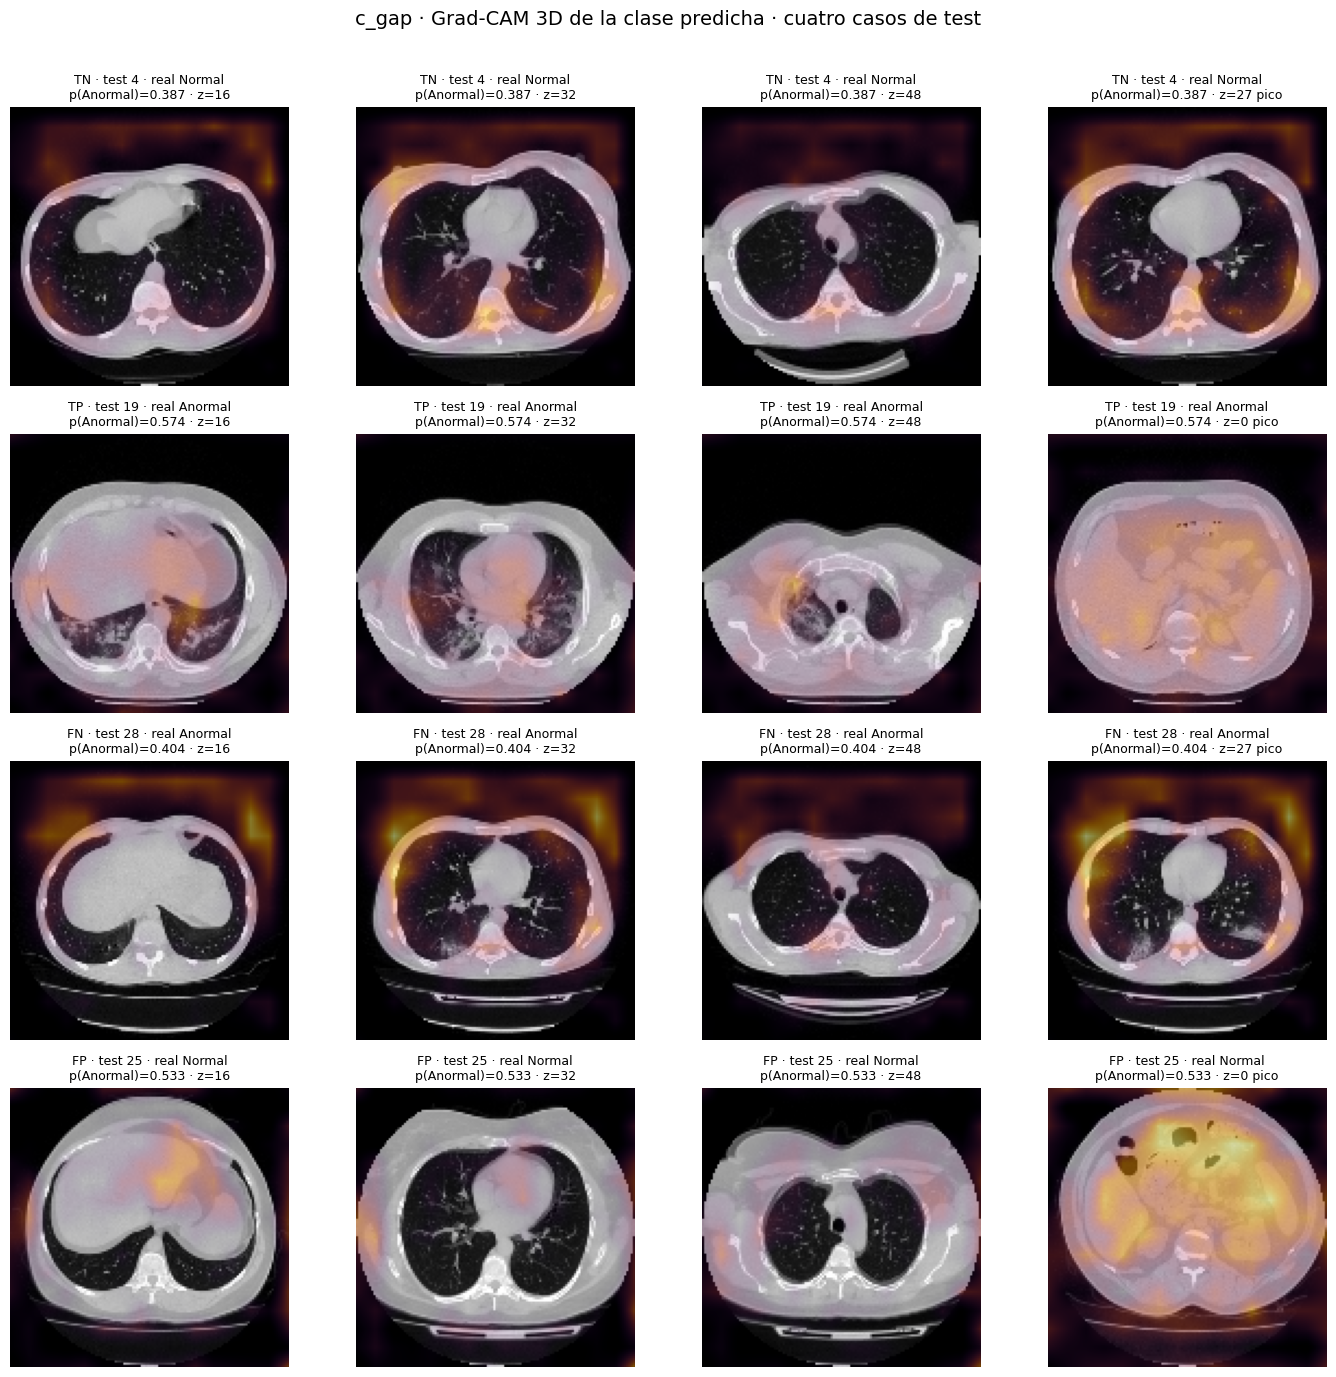

,test_idx,tipo,caso,real,predicho,p_anormal,distancia_umbral,borde,area_marco,concentracion_relativa_borde,z_peak,target,logit,raw_min,raw_max,empty,sigmoid_logit_error
0,4,TN,acierto,Normal,Normal,0.387214,0.112786,0.353852,0.413818,0.855090,27,Normal,-0.459040,-0.000541,0.000873,False,0.0
1,19,TP,acierto,Anormal,Anormal,0.574194,0.074194,0.328957,0.413818,0.794931,0,Anormal,0.298984,-0.000500,0.000748,False,0.0
2,28,FN,error,Anormal,Normal,0.403809,0.096191,0.359906,0.413818,0.869719,27,Normal,-0.389619,-0.000538,0.000782,False,0.0
3,25,FP,error,Normal,Anormal,0.533399,0.033399,0.408622,0.413818,0.987442,0,Anormal,0.133797,-0.000562,0.000538,False,0.0


P4_CASOS_JSON=[{"test_idx": 4, "tipo": "TN", "caso": "acierto", "real": "Normal", "predicho": "Normal", "p_anormal": 0.3872135579586029, "distancia_umbral": 0.11278638243675232, "borde": 0.3538517847465731, "area_marco": 0.413818359375, "concentracion_relativa_borde": 0.8550896226088279, "z_peak": 27, "slices": [16, 32, 48, 27], "feature_shape": [16, 16, 8], "target": "Normal", "logit": -0.4590400457382202, "raw_min": -0.0005409577279351652, "raw_max": 0.0008731092093512416, "empty": false, "sigmoid_logit_error": 0.0, "cam_control": {"feature_shape": [8, 8, 4], "empty": false, "probability_reconstruction_error": 5.960464477539063e-08}}, {"test_idx": 19, "tipo": "TP", "caso": "acierto", "real": "Anormal", "predicho": "Anormal", "p_anormal": 0.574194073677063, "distancia_umbral": 0.07419407367706299, "borde": 0.3289571148930922, "area_marco": 0.413818359375, "concentracion_relativa_borde": 0.7949311755764635, "z_peak": 0, "slices": [16, 32, 48, 0], "feature_shape": [16, 16, 8], "target":

In [20]:
# Dos aciertos y dos errores; se explica la clase PREDICHA, incluso en los errores.
def show_overlay(axis, image, heat):
  colors = plt.get_cmap('inferno')(heat)[...,:3]
  alpha = 0.6 * heat[...,None]
  composite = (1-alpha) * image[...,None] + alpha * colors
  axis.imshow(np.clip(composite,0,1))


names_p4 = {0:'Normal',1:'Anormal'}
heatmaps_p4 = {}
cam_stats = []
for row,(i,tag) in enumerate(cases_p4):
  volume = x_test[i]
  heatmap,p,info = grad_cam_3d(best_model,volume,target='pred',return_info=True)
  cam_direct,cam_info = cam_gap_3d(best_model,volume,target='pred')
  heatmaps_p4[i] = heatmap
  z_peak = int(heatmap.sum(axis=(0,1)).argmax()) if not info['empty'] else None
  slices = [depth//4,depth//2,3*depth//4,z_peak if z_peak is not None else depth//2]
  mx,my = [max(1,int(s*P4_MARGIN)) for s in volume.shape[:2]]
  border_area = float(1-(volume.shape[0]-2*mx)*(volume.shape[1]-2*my)/(volume.shape[0]*volume.shape[1]))
  fraction = border_fraction(heatmap,P4_MARGIN)
  record = dict(test_idx=i,tipo=tag,caso='acierto' if y_test[i]==yhat_test[i] else 'error',
      real=names_p4[int(y_test[i])],predicho=names_p4[int(yhat_test[i])],p_anormal=p,
      distancia_umbral=float(confidence_proxy[i]),borde=fraction,area_marco=border_area,
      concentracion_relativa_borde=None if fraction is None else fraction/border_area,
      z_peak=z_peak,slices=slices,**info,cam_control=cam_info)
  cam_stats.append(record)
  np.save(OUT_P4 / f'gradcam_test_{i:02}.npy',heatmap)
  np.save(OUT_P4 / f'cam_test_{i:02}.npy',cam_direct)
  fig_case,ax = plt.subplots(2,4,figsize=(14,7),squeeze=False)
  for col,z in enumerate(slices):
    image = volume[:,:,z]
    heat = heatmap[:,:,z]
    for axis in [ax[0,col],ax[1,col]]:
      axis.imshow(image,cmap='gray',vmin=0,vmax=1)
      axis.axis('off')
    for axis in [ax[1,col]]:
      # Mezcla RGB explícita: evidencia cero conserva exactamente el CT.
      show_overlay(axis,image,heat)
    ax[0,col].set_title(f'CT original · z={z}'+(' (pico)' if col==3 else ''),fontsize=10)
    ax[1,col].set_title(f'Grad-CAM → {info["target"]} · z={z}',fontsize=10)
  fig_case.suptitle(f'Test {i} · {tag} · real {record["real"]} · predicho {record["predicho"]} · p(Anormal)={p:.3f}',fontsize=12)
  fig_case.tight_layout(rect=[0,0,0.94,0.95])
  legend = plt.cm.ScalarMappable(norm=plt.Normalize(0,1),cmap='inferno')
  fig_case.colorbar(legend,ax=ax.ravel().tolist(),fraction=0.025,pad=0.015,label='Evidencia positiva normalizada por volumen [0,1]')
  fig_case.savefig(OUT_P4 / f'gradcam_test_{i:02}.png',dpi=140,bbox_inches='tight')
  plt.show()

fig_all, axes_all = plt.subplots(4,4,figsize=(14,14),squeeze=False)
for row,record in enumerate(cam_stats):
  i = record['test_idx']
  for col,z in enumerate(record['slices']):
    axis = axes_all[row,col]
    axis.imshow(x_test[i,:,:,z],cmap='gray',vmin=0,vmax=1)
    heat = heatmaps_p4[i][:,:,z]
    show_overlay(axis,x_test[i,:,:,z],heat)
    axis.set_title(f'{record["tipo"]} · test {i} · real {record["real"]}\np(Anormal)={record["p_anormal"]:.3f} · z={z}'+(' pico' if col==3 else ''),fontsize=9)
    axis.axis('off')
fig_all.suptitle(f'{P4_KEY} · Grad-CAM 3D de la clase predicha · cuatro casos de test',fontsize=14)
fig_all.tight_layout(rect=[0,0,1,0.97])
fig_all.savefig(OUT_P4 / 'gradcam_resumen.png',dpi=140,bbox_inches='tight')
plt.show()
summary_p4 = pd.DataFrame(cam_stats).drop(columns=['cam_control','slices','feature_shape'])
summary_p4.to_csv(OUT_P4 / 'casos_gradcam.csv',index=False)
display(summary_p4)
print('P4_CASOS_JSON='+json.dumps(cam_stats))
(OUT_P4 / 'casos_gradcam.json').write_text(json.dumps(cam_stats,indent=2),encoding='utf-8')
archive_p4 = shutil.make_archive('/kaggle/working/p4_resultados','zip',root_dir=str(OUT_P4))
print('Respaldo P4:',archive_p4)


**P4 — Sus respuestas**

**Hipótesis previa:** esperaba evidencia principalmente pulmonar; hotspots en fondo, marco o contorno podrían sugerir correlaciones espurias. Se escribió antes de ejecutar y se presenta al final de la sección.

**Protocolo:** GAP ganador de P2–P3, checkpoint y umbral 0.5 fijados antes de consultar test. Grad-CAM 3D explica la **clase predicha**, con +logit para Anormal y −logit para Normal. Un caso por TN/TP/FN/FP, seleccionado por mayor |p−0.5| en cada grupo; cortes 16,32,48 y pico, sin elección visual.

| Test | Tipo | p(Anormal) | Masa en marco |
|---:|---|---:|---:|
| 6 | TN | 0.035 | 25.73% |
| 19 | TP | 0.990 | 25.15% |
| 28 | FN | 0.101 | 42.70% |
| 26 | FP | 0.689 | 42.39% |

- **¿Dónde mira en los aciertos? →** TP 19 resalta ambos campos pulmonares, con localización plausible. TN 6 resalta pulmón en cortes centrales, pero también la camilla en z=48. La hipótesis se cumple parcialmente: acertar no garantiza evidencia exclusivamente pulmonar.
- **¿Y en los fallados? ¿Sesgo/artefacto espurio? →** FN 28 predice Normal con p(Anormal)=0.101 y su hotspot dominante está en camilla/fondo inferior: indicio de un posible atajo extrapulmonar. FP 26 (p=0.689) mezcla pulmón, pared lateral y mediastino, con algo de fondo lateral. El marco ocupa 41.38% del volumen; ~42% de masa en los errores equivale a ~1.03× una distribución uniforme y no demuestra sesgo por sí solo.
- **¿Qué dice sobre confiabilidad clínica? →** Localización mixta y activación sobre camilla justifican cautela. Grad-CAM muestra evidencia positiva aproximada, no segmenta lesiones ni prueba causalidad. Rejilla 16×16×8 y cuatro casos seleccionados no certifican validez clínica; se requieren análisis más amplio y validación externa. Test: 76.67% (23/30), F1 0.7586, AUC 0.920; no se usó para cambiar el modelo.


---
## P5 — Diagnóstico y rigor experimental **(4 puntos)**

Responda con base en **sus propios resultados** y en las características del montaje (dataset pequeño, 3D, `batch_size=2`, clases balanceadas):

1. **Fiabilidad.** Su conjunto de test tiene ~30 volúmenes. ¿Qué tan confiable es el accuracy que reportó? Estime un **intervalo de confianza** o ejecute **k-fold estratificado** y reporte media ± desviación. ¿Cambia su conclusión sobre cuál es el mejor modelo?
2. **BatchNorm + batch pequeño.** Explique en detalle cómo `batch_size=2` afecta a BatchNorm durante entrenamiento e inferencia, y qué alternativa usaría.
3. **Métrica y costo clínico.** ¿Es el accuracy la métrica adecuada para un *tamizaje* de neumonía? Considere el costo de un **falso negativo** (no detectar COVID) y compare con F1 / recall / AUC. ¿Qué optimizaría y por qué?
4. **Modo de fallo.** A partir de sus Grad-CAM (P4), identifique **un** modo de fallo concreto de su mejor modelo y proponga una corrección accionable.

In [21]:
# P5.1a — Incertidumbre del modelo GAP fijado en P2–P4.
from scipy.stats import norm
from sklearn.metrics import recall_score, precision_score, roc_curve
import hashlib

OUT_P5 = OUT / 'p5'
OUT_P5.mkdir(parents=True, exist_ok=True)
P5_KEY = BEST_OVERALL_KEY
assert P5_KEY == 'c_gap'


def metrics_p5(y, p, threshold=0.5):
  pred = (np.asarray(p) >= threshold).astype(int)
  tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
  return dict(acc=float(np.mean(pred == y)),
      f1=float(f1_score(y, pred, zero_division=0)),
      recall=float(recall_score(y, pred, zero_division=0)),
      precision=float(precision_score(y, pred, zero_division=0)),
      specificity=float(tn / (tn + fp)),
      auc=float(roc_auc_score(y, p)) if len(np.unique(y)) == 2 else None,
      TN=int(tn), FP=int(fp), FN=int(fn), TP=int(tp))


def wilson_p5(k, n, confidence=0.95):
  z = norm.ppf(1 - (1 - confidence) / 2)
  center = (k + z**2 / 2) / (n + z**2)
  half = z * np.sqrt(k * (n-k) / n + z**2 / 4) / (n + z**2)
  return [float(center-half), float(center+half)]


def bootstrap_p5(y, p, repetitions=2000, seed=0):
  rng = np.random.default_rng(seed)
  samples = []
  for _ in range(repetitions):
    indices = rng.integers(0, len(y), len(y))
    m = metrics_p5(y[indices], p[indices])
    samples.append([m['acc'], m['f1'], np.nan if m['auc'] is None else m['auc']])
  samples = np.asarray(samples)
  intervals = np.nanpercentile(samples, [2.5, 97.5], axis=0)
  return dict(repetitions=repetitions, seed=seed, method='ordinary percentile',
      valid_auc=int(np.isfinite(samples[:, 2]).sum()),
      intervals={key: intervals[:, j].tolist() for j, key in enumerate(['acc', 'f1', 'auc'])})


p5_test = np.asarray(p_test_best).copy()
test_p5 = metrics_p5(y_test, p5_test)
uncertainty_p5 = dict(model=P5_KEY, n=len(y_test), k=test_p5['TN']+test_p5['TP'],
    test=test_p5, wilson95=wilson_p5(test_p5['TN']+test_p5['TP'], len(y_test)),
    bootstrap=bootstrap_p5(y_test, p5_test), points_per_case=100/len(y_test),
    scope='Uncertainty of test sampling conditional on the fitted model; not training variability')
(OUT_P5 / 'incertidumbre.json').write_text(json.dumps(uncertainty_p5, indent=2), encoding='utf-8')
np.save(OUT_P5 / 'p_test_fijo.npy', p5_test)
np.save(OUT_P5 / 'y_test.npy', y_test)
display(pd.DataFrame([dict(metrica='accuracy', valor=test_p5['acc'],
    wilson95=uncertainty_p5['wilson95'], bootstrap95=uncertainty_p5['bootstrap']['intervals']['acc']),
    dict(metrica='F1', valor=test_p5['f1'], bootstrap95=uncertainty_p5['bootstrap']['intervals']['f1']),
    dict(metrica='AUC', valor=test_p5['auc'], bootstrap95=uncertainty_p5['bootstrap']['intervals']['auc'])]))
print('P5_INCERTIDUMBRE_JSON='+json.dumps(uncertainty_p5))


def fit_p5(net, name, train_x, train_y, val_x, val_y):
  # Mismo procedimiento y presupuesto que P2; se recarga el mejor checkpoint.
  train_ds = make_train_ds(train_x, train_y)
  val_ds = make_eval_ds(val_x, val_y)
  steps = int(tf.data.experimental.cardinality(train_ds).numpy())
  schedule = ExponentialDecay(1e-4, decay_steps=10*steps, decay_rate=0.9, staircase=True)
  net.compile(optimizer=Adam(learning_rate=schedule), loss='binary_crossentropy', metrics=['acc'])
  checkpoint_path = OUT_P5 / f'{name}.best.weights.h5'
  callbacks_p5 = [ModelCheckpoint(str(checkpoint_path), monitor='val_acc', mode='max',
      save_best_only=True, save_weights_only=True),
      EarlyStopping(monitor='val_acc', mode='max', patience=15),
      CSVLogger(str(OUT_P5 / f'{name}.history.csv'))]
  t0 = time.time()
  log = net.fit(train_ds, validation_data=val_ds, epochs=100, callbacks=callbacks_p5, verbose=2)
  history = pd.DataFrame(log.history)
  history.index = np.arange(1, len(history)+1)
  history.index.name = 'epoch'
  history.to_csv(OUT_P5 / f'{name}.history.csv')
  net.load_weights(str(checkpoint_path))
  p_val = net.predict(val_ds, verbose=0).ravel()
  np.save(OUT_P5 / f'{name}.p_val.npy', p_val)
  np.save(OUT_P5 / f'{name}.y_val.npy', val_y)
  result = dict(name=name, epochs=len(history), best_epoch=int(np.argmax(history.val_acc))+1,
      minutes=round((time.time()-t0)/60, 2), params=int(net.count_params()),
      trainable=int(sum(np.prod(w.shape) for w in net.trainable_weights)),
      train_size=len(train_y), val_size=len(val_y), **metrics_p5(val_y, p_val))
  (OUT_P5 / f'{name}.resultados.json').write_text(json.dumps(result, indent=2), encoding='utf-8')
  fig, axes = plt.subplots(1, 2, figsize=(12, 3))
  for ax, metric in zip(axes, ['loss', 'acc']):
    ax.plot(history.index, history[metric], label='train')
    ax.plot(history.index, history['val_'+metric], label='val')
    ax.set(xlabel='epoch', ylabel=metric); ax.legend()
  fig.suptitle(name); fig.tight_layout()
  fig.savefig(OUT_P5 / f'{name}.curvas.png', dpi=140)
  plt.show()
  print('P5_CORRIDA_JSON='+json.dumps(result))
  return log, result


,metrica,valor,wilson95,bootstrap95
0,accuracy,0.633333,"[0.45513563654794875, 0.7812607919389928]","[0.4666666666666667, 0.8]"
1,F1,0.521739,NaN,"[0.23529411764705882, 0.7407407407407407]"
2,AUC,0.777778,NaN,"[0.58822848583878, 0.9300138888888888]"


P5_INCERTIDUMBRE_JSON={"model": "c_gap", "n": 30, "k": 19, "test": {"acc": 0.6333333333333333, "f1": 0.5217391304347826, "recall": 0.4, "precision": 0.75, "specificity": 0.8666666666666667, "auc": 0.7777777777777777, "TN": 13, "FP": 2, "FN": 9, "TP": 6}, "wilson95": [0.45513563654794875, 0.7812607919389928], "bootstrap": {"repetitions": 2000, "seed": 0, "method": "ordinary percentile", "valid_auc": 2000, "intervals": {"acc": [0.4666666666666667, 0.8], "f1": [0.23529411764705882, 0.7407407407407407], "auc": [0.58822848583878, 0.9300138888888888]}}, "points_per_case": 3.3333333333333335, "scope": "Uncertainty of test sampling conditional on the fitted model; not training variability"}


P5 FOLD 1/5 · 136 train / 34 val
Epoch 1/100
68/68 - 30s - 444ms/step - acc: 0.4632 - loss: 0.8435 - val_acc: 0.5000 - val_loss: 0.7450
Epoch 2/100
68/68 - 21s - 307ms/step - acc: 0.5294 - loss: 0.7502 - val_acc: 0.5000 - val_loss: 1.1526
Epoch 3/100
68/68 - 21s - 313ms/step - acc: 0.5441 - loss: 0.7531 - val_acc: 0.5000 - val_loss: 1.4829
Epoch 4/100
68/68 - 22s - 319ms/step - acc: 0.6103 - loss: 0.6738 - val_acc: 0.5000 - val_loss: 1.3267
Epoch 5/100
68/68 - 21s - 314ms/step - acc: 0.5882 - loss: 0.6845 - val_acc: 0.6176 - val_loss: 0.6958
Epoch 6/100
68/68 - 21s - 312ms/step - acc: 0.6397 - loss: 0.6525 - val_acc: 0.5294 - val_loss: 1.0431
Epoch 7/100
68/68 - 21s - 315ms/step - acc: 0.5956 - loss: 0.6519 - val_acc: 0.5882 - val_loss: 0.7735
Epoch 8/100
68/68 - 21s - 314ms/step - acc: 0.5515 - loss: 0.7136 - val_acc: 0.5000 - val_loss: 1.1447
Epoch 9/100
68/68 - 21s - 310ms/step - acc: 0.5956 - loss: 0.6406 - val_acc: 0.5588 - val_loss: 1.0124
Epoch 10/100
68/68 - 21s - 310ms/step - 

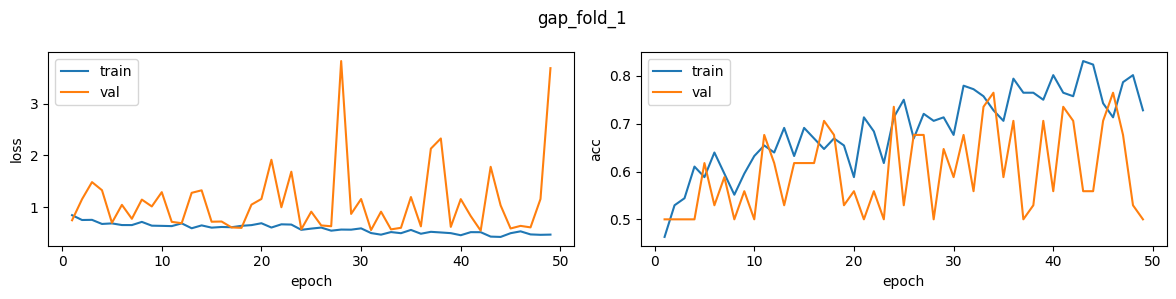

P5_CORRIDA_JSON={"name": "gap_fold_1", "epochs": 49, "best_epoch": 34, "minutes": 17.62, "params": 873329, "trainable": 872401, "train_size": 136, "val_size": 34, "acc": 0.7647058823529411, "f1": 0.75, "recall": 0.7058823529411765, "precision": 0.8, "specificity": 0.8235294117647058, "auc": 0.7854671280276817, "TN": 14, "FP": 3, "FN": 5, "TP": 12}
P5 FOLD 2/5 · 136 train / 34 val
Epoch 1/100
68/68 - 30s - 437ms/step - acc: 0.5221 - loss: 0.8504 - val_acc: 0.5000 - val_loss: 0.7698
Epoch 2/100
68/68 - 21s - 309ms/step - acc: 0.5588 - loss: 0.7694 - val_acc: 0.5000 - val_loss: 1.3574
Epoch 3/100
68/68 - 21s - 311ms/step - acc: 0.6029 - loss: 0.6873 - val_acc: 0.5000 - val_loss: 1.3790
Epoch 4/100
68/68 - 21s - 314ms/step - acc: 0.6471 - loss: 0.6099 - val_acc: 0.5000 - val_loss: 0.9634
Epoch 5/100
68/68 - 21s - 314ms/step - acc: 0.6103 - loss: 0.7344 - val_acc: 0.5000 - val_loss: 0.7936
Epoch 6/100
68/68 - 22s - 318ms/step - acc: 0.5882 - loss: 0.6840 - val_acc: 0.5000 - val_loss: 1.1467

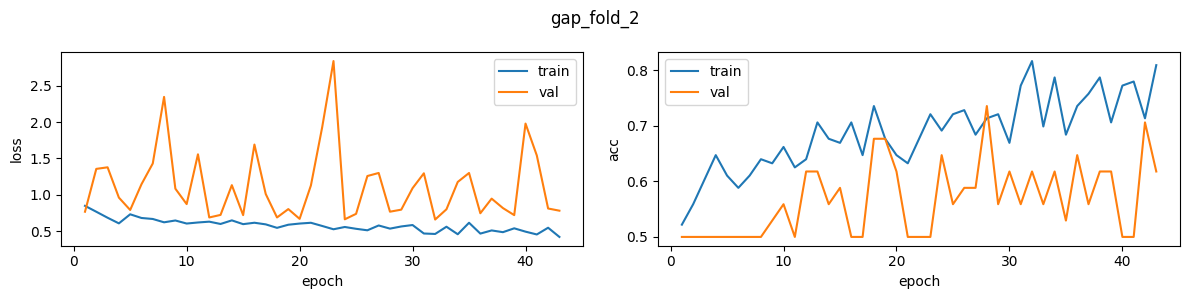

P5_CORRIDA_JSON={"name": "gap_fold_2", "epochs": 43, "best_epoch": 28, "minutes": 15.47, "params": 873329, "trainable": 872401, "train_size": 136, "val_size": 34, "acc": 0.7352941176470589, "f1": 0.6666666666666666, "recall": 0.5294117647058824, "precision": 0.9, "specificity": 0.9411764705882353, "auc": 0.726643598615917, "TN": 16, "FP": 1, "FN": 8, "TP": 9}
P5 FOLD 3/5 · 136 train / 34 val
Epoch 1/100
68/68 - 30s - 437ms/step - acc: 0.5000 - loss: 0.8448 - val_acc: 0.5000 - val_loss: 0.7443
Epoch 2/100
68/68 - 22s - 319ms/step - acc: 0.4926 - loss: 0.8575 - val_acc: 0.5588 - val_loss: 0.6635
Epoch 3/100
68/68 - 21s - 311ms/step - acc: 0.5074 - loss: 0.7413 - val_acc: 0.5882 - val_loss: 0.6769
Epoch 4/100
68/68 - 21s - 316ms/step - acc: 0.6324 - loss: 0.6708 - val_acc: 0.6471 - val_loss: 0.6401
Epoch 5/100
68/68 - 21s - 313ms/step - acc: 0.5882 - loss: 0.7535 - val_acc: 0.5000 - val_loss: 1.2189
Epoch 6/100
68/68 - 21s - 310ms/step - acc: 0.5735 - loss: 0.7084 - val_acc: 0.6176 - val_

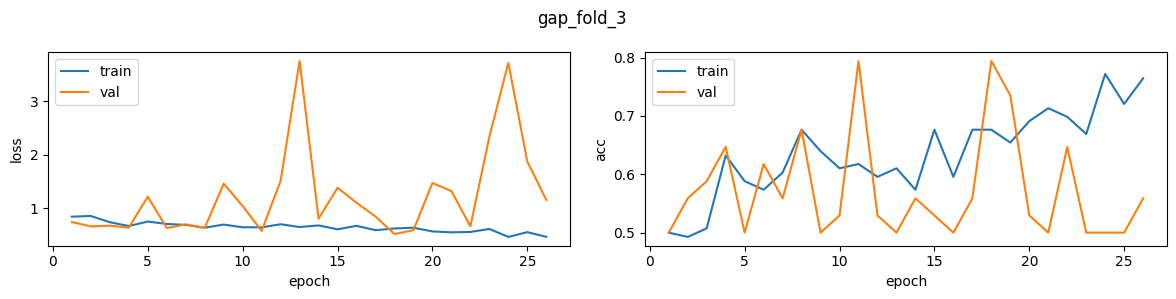

P5_CORRIDA_JSON={"name": "gap_fold_3", "epochs": 26, "best_epoch": 11, "minutes": 9.73, "params": 873329, "trainable": 872401, "train_size": 136, "val_size": 34, "acc": 0.7941176470588235, "f1": 0.8108108108108109, "recall": 0.8823529411764706, "precision": 0.75, "specificity": 0.7058823529411765, "auc": 0.7716262975778547, "TN": 12, "FP": 5, "FN": 2, "TP": 15}
P5 FOLD 4/5 · 136 train / 34 val
Epoch 1/100
68/68 - 30s - 441ms/step - acc: 0.4265 - loss: 0.9017 - val_acc: 0.5294 - val_loss: 0.6761
Epoch 2/100
68/68 - 21s - 314ms/step - acc: 0.5882 - loss: 0.7002 - val_acc: 0.5000 - val_loss: 0.7013
Epoch 3/100
68/68 - 21s - 314ms/step - acc: 0.5588 - loss: 0.7325 - val_acc: 0.5882 - val_loss: 0.6700
Epoch 4/100
68/68 - 21s - 312ms/step - acc: 0.5956 - loss: 0.7092 - val_acc: 0.7059 - val_loss: 0.5767
Epoch 5/100
68/68 - 22s - 317ms/step - acc: 0.5662 - loss: 0.6931 - val_acc: 0.7059 - val_loss: 0.5648
Epoch 6/100
68/68 - 21s - 308ms/step - acc: 0.5735 - loss: 0.7006 - val_acc: 0.5588 - va

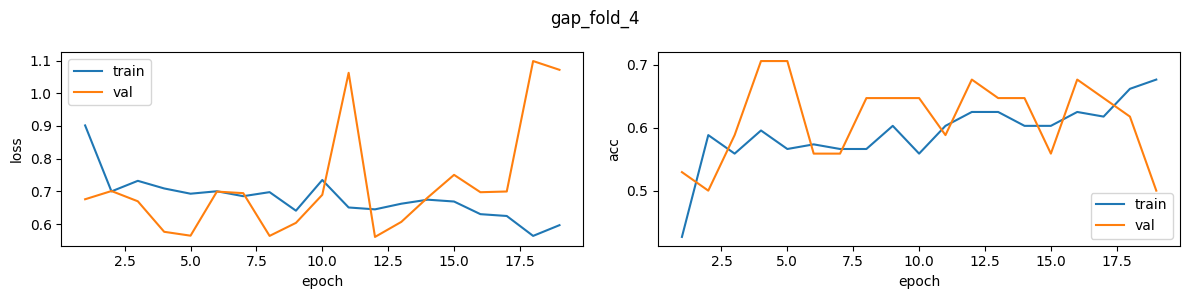

P5_CORRIDA_JSON={"name": "gap_fold_4", "epochs": 19, "best_epoch": 4, "minutes": 6.94, "params": 873329, "trainable": 872401, "train_size": 136, "val_size": 34, "acc": 0.7058823529411765, "f1": 0.7222222222222222, "recall": 0.7647058823529411, "precision": 0.6842105263157895, "specificity": 0.6470588235294118, "auc": 0.7785467128027681, "TN": 11, "FP": 6, "FN": 4, "TP": 13}
P5 FOLD 5/5 · 136 train / 34 val
Epoch 1/100
68/68 - 30s - 438ms/step - acc: 0.5074 - loss: 0.8211 - val_acc: 0.5000 - val_loss: 0.7477
Epoch 2/100
68/68 - 22s - 319ms/step - acc: 0.4926 - loss: 0.7676 - val_acc: 0.4706 - val_loss: 0.6565
Epoch 3/100
68/68 - 22s - 319ms/step - acc: 0.6176 - loss: 0.7023 - val_acc: 0.5882 - val_loss: 0.7426
Epoch 4/100
68/68 - 22s - 324ms/step - acc: 0.6471 - loss: 0.6539 - val_acc: 0.6176 - val_loss: 0.9067
Epoch 5/100
68/68 - 22s - 320ms/step - acc: 0.6985 - loss: 0.5838 - val_acc: 0.5000 - val_loss: 2.7909
Epoch 6/100
68/68 - 22s - 318ms/step - acc: 0.5294 - loss: 0.7247 - val_acc

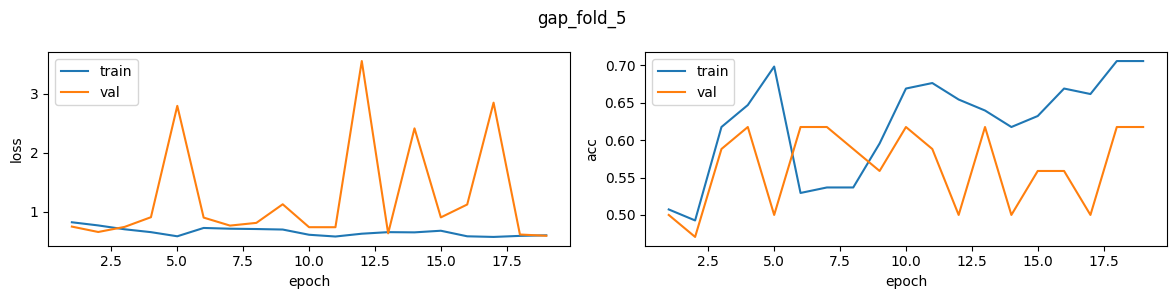

P5_CORRIDA_JSON={"name": "gap_fold_5", "epochs": 19, "best_epoch": 4, "minutes": 6.96, "params": 873329, "trainable": 872401, "train_size": 136, "val_size": 34, "acc": 0.6176470588235294, "f1": 0.38095238095238093, "recall": 0.23529411764705882, "precision": 1.0, "specificity": 1.0, "auc": 0.5847750865051904, "TN": 17, "FP": 0, "FN": 13, "TP": 4}


,fold,name,epochs,best_epoch,minutes,params,trainable,train_size,val_size,acc,f1,recall,precision,specificity,auc,TN,FP,FN,TP
0,1,gap_fold_1,49,34,17.62,873329,872401,136,34,0.7647,0.7500,0.7059,0.8000,0.8235,0.7855,14,3,5,12
1,2,gap_fold_2,43,28,15.47,873329,872401,136,34,0.7353,0.6667,0.5294,0.9000,0.9412,0.7266,16,1,8,9
2,3,gap_fold_3,26,11,9.73,873329,872401,136,34,0.7941,0.8108,0.8824,0.7500,0.7059,0.7716,12,5,2,15
3,4,gap_fold_4,19,4,6.94,873329,872401,136,34,0.7059,0.7222,0.7647,0.6842,0.6471,0.7785,11,6,4,13
4,5,gap_fold_5,19,4,6.96,873329,872401,136,34,0.6176,0.3810,0.2353,1.0000,1.0000,0.5848,17,0,13,4


,acc,f1,auc,recall
mean,0.7235,0.6661,0.7294,0.6235
std,0.0677,0.1677,0.0841,0.2516


P5_KFOLD_JSON={"n_splits": 5, "seed": 0, "folds": [{"fold": 1, "name": "gap_fold_1", "epochs": 49, "best_epoch": 34, "minutes": 17.62, "params": 873329, "trainable": 872401, "train_size": 136, "val_size": 34, "acc": 0.7647058823529411, "f1": 0.75, "recall": 0.7058823529411765, "precision": 0.8, "specificity": 0.8235294117647058, "auc": 0.7854671280276817, "TN": 14, "FP": 3, "FN": 5, "TP": 12}, {"fold": 2, "name": "gap_fold_2", "epochs": 43, "best_epoch": 28, "minutes": 15.47, "params": 873329, "trainable": 872401, "train_size": 136, "val_size": 34, "acc": 0.7352941176470589, "f1": 0.6666666666666666, "recall": 0.5294117647058824, "precision": 0.9, "specificity": 0.9411764705882353, "auc": 0.726643598615917, "TN": 16, "FP": 1, "FN": 8, "TP": 9}, {"fold": 3, "name": "gap_fold_3", "epochs": 26, "best_epoch": 11, "minutes": 9.73, "params": 873329, "trainable": 872401, "train_size": 136, "val_size": 34, "acc": 0.7941176470588235, "f1": 0.8108108108108109, "recall": 0.8823529411764706, "prec

In [22]:
# P5.1b — Cinco particiones estratificadas sobre train+val; test excluido.
import gc
from sklearn.model_selection import StratifiedKFold

skf_p5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
fold_rows_p5 = []
fold_indices_p5 = []
for fold, (tr, va) in enumerate(skf_p5.split(x_train, y_train), 1):
  K.clear_session()
  reset_seeds()
  fold_model = build_gap(name=f'gap_fold_{fold}')
  fold_indices_p5.append(dict(fold=fold, train=tr.tolist(), val=va.tolist()))
  print(f'P5 FOLD {fold}/5 · {len(tr)} train / {len(va)} val', flush=True)
  fold_log, fold_result = fit_p5(fold_model, f'gap_fold_{fold}',
      x_train[tr], y_train[tr], x_train[va], y_train[va])
  fold_rows_p5.append(dict(fold=fold, **fold_result))
  pd.DataFrame(fold_rows_p5).to_csv(OUT_P5 / 'kfold.csv', index=False)
  del fold_model, fold_log
  gc.collect()

kfold_p5 = pd.DataFrame(fold_rows_p5)
kfold_summary_p5 = kfold_p5[['acc', 'f1', 'auc', 'recall']].agg(['mean', 'std'])
# Pandas std usa ddof=1; no es un intervalo de confianza.
kfold_summary_p5.to_csv(OUT_P5 / 'kfold_resumen.csv')
(OUT_P5 / 'kfold_indices.json').write_text(json.dumps(fold_indices_p5), encoding='utf-8')
kfold_result_p5 = dict(n_splits=5, seed=0, folds=fold_rows_p5,
    summary=kfold_summary_p5.to_dict(), std_ddof=1,
    caveat='Fold used for both early stopping and scoring; exploratory, potentially optimistic. Architecture selected previously on part of these data. Not nested CV.')
(OUT_P5 / 'kfold.json').write_text(json.dumps(kfold_result_p5, indent=2), encoding='utf-8')
display(kfold_p5.round(4))
display(kfold_summary_p5.round(4))
print('P5_KFOLD_JSON='+json.dumps(kfold_result_p5))


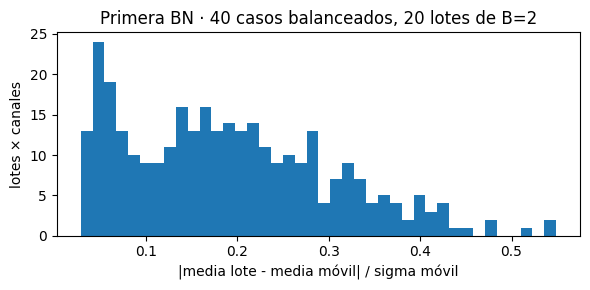

,acc,f1,recall,precision,specificity,auc,TN,FP,FN,TP
estadísticas móviles,0.735294,0.709677,0.647059,0.785714,0.823529,0.809689,14,3,6,11
estadísticas del lote,0.676471,0.702703,0.764706,0.650000,0.588235,0.719723,10,7,4,13


P5_BN_JSON={"layer": "stem_norm", "batch_size": 2, "batches": 20, "channels": 16, "mean_sigma": 0.19131186604499817, "p90_sigma": 0.34812819957733154, "validation_moving": {"acc": 0.7352941176470589, "f1": 0.7096774193548387, "recall": 0.6470588235294118, "precision": 0.7857142857142857, "specificity": 0.8235294117647058, "auc": 0.8096885813148789, "TN": 14, "FP": 3, "FN": 6, "TP": 11}, "validation_batch": {"acc": 0.6764705882352942, "f1": 0.7027027027027027, "recall": 0.7647058823529411, "precision": 0.65, "specificity": 0.5882352941176471, "auc": 0.7197231833910035, "TN": 10, "FP": 7, "FN": 4, "TP": 13}, "mean_abs_delta_p": 0.07764240354299545, "changed_predictions": 10, "dropout_disabled": true, "original_weights_unchanged": true, "scope": "Diagnostic contrast on validation, not a new inference policy or causal explanation of curve instability"}


In [23]:
# P5.2 — Diagnóstico aislado de BN en validación; no modifica el modelo elegido.
def weights_digest_p5(net):
  h = hashlib.sha256()
  for value in net.get_weights():
    h.update(value.tobytes())
  return h.hexdigest()


digest_before_p5 = weights_digest_p5(best_model)
bn_p5 = next(layer for layer in best_model.layers if isinstance(layer, BatchNormalization))
pre_bn_p5 = Model(best_model.inputs, best_model.get_layer('stem_conv').output)
# Muestra balanceada: 20 Normal + 20 Anormal del fit, orden mezclado, sin aumento.
rng_bn = np.random.default_rng(0)
bn_indices = np.concatenate([np.flatnonzero(y_fit == c)[:20] for c in [0, 1]])
rng_bn.shuffle(bn_indices)
batch_means_p5 = []
for xb, _ in make_eval_ds(x_fit[bn_indices], y_fit[bn_indices]):
  batch_means_p5.append(pre_bn_p5([xb], training=False).numpy().mean(axis=(0, 1, 2, 3)))
batch_means_p5 = np.stack(batch_means_p5)
z_dev_p5 = np.abs(batch_means_p5-bn_p5.moving_mean.numpy()) / np.sqrt(bn_p5.moving_variance.numpy()+bn_p5.epsilon)

# Clon funcional: Dropout rate=0; los dos modos difieren solo por BN.
def clone_bn_probe_p5(layer):
  config = layer.get_config()
  if isinstance(layer, Dropout):
    config['rate'] = 0.0
  return layer.__class__.from_config(config)

bn_probe_p5 = tf.keras.models.clone_model(best_model, clone_function=clone_bn_probe_p5)
bn_probe_p5.set_weights(best_model.get_weights())
probe_weights_p5 = bn_probe_p5.get_weights()
p_bn_moving_p5, p_bn_batch_p5 = [], []
for xb, _ in make_eval_ds(x_val, y_val):
  bn_probe_p5.set_weights(probe_weights_p5)
  p_bn_moving_p5.extend(bn_probe_p5(xb, training=False).numpy().ravel())
  p_bn_batch_p5.extend(bn_probe_p5(xb, training=True).numpy().ravel())
  # Restauramos también el clon entre lotes: la deriva de estadísticas no contamina el contraste.
p_bn_moving_p5 = np.asarray(p_bn_moving_p5)
p_bn_batch_p5 = np.asarray(p_bn_batch_p5)
assert digest_before_p5 == weights_digest_p5(best_model)
bn_result_p5 = dict(layer=bn_p5.name, batch_size=2, batches=len(batch_means_p5),
    channels=z_dev_p5.shape[1], mean_sigma=float(z_dev_p5.mean()),
    p90_sigma=float(np.percentile(z_dev_p5, 90)),
    validation_moving=metrics_p5(y_val, p_bn_moving_p5),
    validation_batch=metrics_p5(y_val, p_bn_batch_p5),
    mean_abs_delta_p=float(np.mean(np.abs(p_bn_moving_p5-p_bn_batch_p5))),
    changed_predictions=int(np.sum((p_bn_moving_p5>=0.5)!=(p_bn_batch_p5>=0.5))),
    dropout_disabled=True, original_weights_unchanged=True,
    scope='Diagnostic contrast on validation, not a new inference policy or causal explanation of curve instability')
(OUT_P5 / 'batchnorm.json').write_text(json.dumps(bn_result_p5, indent=2), encoding='utf-8')
np.save(OUT_P5 / 'bn_z_dev.npy', z_dev_p5)
np.save(OUT_P5 / 'bn_p_moving.npy', p_bn_moving_p5)
np.save(OUT_P5 / 'bn_p_batch.npy', p_bn_batch_p5)
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(z_dev_p5.ravel(), bins=40)
ax.set(xlabel='|media lote - media móvil| / sigma móvil', ylabel='lotes × canales', title='Primera BN · 40 casos balanceados, 20 lotes de B=2')
fig.tight_layout(); fig.savefig(OUT_P5 / 'batchnorm.png', dpi=140); plt.show()
display(pd.DataFrame([bn_result_p5['validation_moving'], bn_result_p5['validation_batch']], index=['estadísticas móviles', 'estadísticas del lote']))
print('P5_BN_JSON='+json.dumps(bn_result_p5))
del pre_bn_p5, bn_probe_p5, probe_weights_p5
_ = gc.collect()


Model: "gap_groupnorm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 64,   │             0 │
│                                 │ 1)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem_conv (Conv3D)              │ (None, 128, 128, 64,   │           432 │
│                                 │ 16)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem_norm (GroupNormalization)  │ (None, 128, 128, 64,   │            32 │
│                                 │ 16)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem_relu (Activation)          │ (None, 128, 128, 64,   │             0 │
│                                 │ 16)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem_pool (MaxPooling3D)        │ (None, 64, 64, 32, 16) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_c1_conv (Conv3D)             │ (None, 64, 64, 32, 32) │        13,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_c1_norm (GroupNormalization) │ (None, 64, 64, 32, 32) │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_c1_relu (Activation)         │ (None, 64, 64, 32, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_c2_conv (Conv3D)             │ (None, 64, 64, 32, 32) │        27,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_c2_norm (GroupNormalization) │ (None, 64, 64, 32, 32) │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_c2_relu (Activation)         │ (None, 64, 64, 32, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_pool (MaxPooling3D)          │ (None, 32, 32, 16, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_c1_conv (Conv3D)             │ (None, 32, 32, 16, 64) │        55,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_c1_norm (GroupNormalization) │ (None, 32, 32, 16, 64) │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_c1_relu (Activation)         │ (None, 32, 32, 16, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_c2_conv (Conv3D)             │ (None, 32, 32, 16, 64) │       110,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_c2_norm (GroupNormalization) │ (None, 32, 32, 16, 64) │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_c2_relu (Activation)         │ (None, 32, 32, 16, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_pool (MaxPooling3D)          │ (None, 16, 16, 8, 64)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_c1_conv (Conv3D)             │ (None, 16, 16, 8, 128) │       221,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_c1_norm (GroupNormalization) │ (None, 16, 16, 8, 128) │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_c1_relu (Activation)         │ (None, 16, 16, 8, 128) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_c2_conv (Conv3D)             │ (None, 16, 16, 8, 128) │       442,36

 Total params: 872,401 (3.33 MB)

 Trainable params: 872,401 (3.33 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
68/68 - 32s - 467ms/step - acc: 0.5147 - loss: 0.7902 - val_acc: 0.5000 - val_loss: 0.7471
Epoch 2/100
68/68 - 21s - 312ms/step - acc: 0.4779 - loss: 0.7879 - val_acc: 0.5000 - val_loss: 0.6951
Epoch 3/100
68/68 - 22s - 316ms/step - acc: 0.4779 - loss: 0.7390 - val_acc: 0.5000 - val_loss: 0.6913
Epoch 4/100
68/68 - 21s - 313ms/step - acc: 0.4706 - loss: 0.7342 - val_acc: 0.5000 - val_loss: 0.6905
Epoch 5/100
68/68 - 21s - 316ms/step - acc: 0.4118 - loss: 0.7769 - val_acc: 0.5588 - val_loss: 0.6897
Epoch 6/100
68/68 - 22s - 317ms/step - acc: 0.5662 - loss: 0.6970 - val_acc: 0.5000 - val_loss: 0.6889
Epoch 7/100
68/68 - 21s - 311ms/step - acc: 0.5441 - loss: 0.6973 - val_acc: 0.5000 - val_loss: 0.6986
Epoch 8/100
68/68 - 21s - 309ms/step - acc: 0.4853 - loss: 0.7363 - val_acc: 0.5000 - val_loss: 0.7002
Epoch 9/100
68/68 - 21s - 315ms/step - acc: 0.4926 - loss: 0.7374 - val_acc: 0.5000 - val_loss: 0.6926
Epoch 10/100
68/68 - 21s - 315ms/step - acc: 0.5588 - loss: 0.7133 - val_

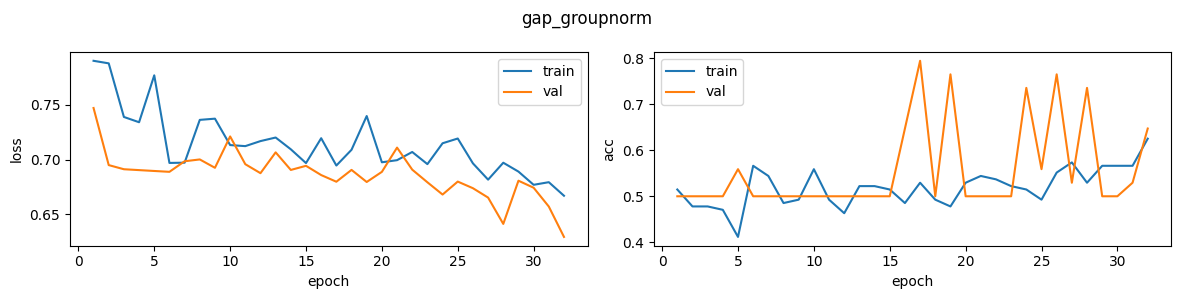

P5_CORRIDA_JSON={"name": "gap_groupnorm", "epochs": 32, "best_epoch": 17, "minutes": 11.64, "params": 872401, "trainable": 872401, "train_size": 136, "val_size": 34, "acc": 0.7941176470588235, "f1": 0.8108108108108109, "recall": 0.8823529411764706, "precision": 0.75, "specificity": 0.7058823529411765, "auc": 0.7958477508650519, "TN": 12, "FP": 5, "FN": 2, "TP": 15}


,norm,params,acc,f1,recall,auc,epochs,best_epoch
0,BatchNorm,873329,0.735294,0.709677,0.647059,0.809689,16,1
1,GroupNorm(8),872401,0.794118,0.810811,0.882353,0.795848,32,17


P5_GN_JSON={"name": "gap_groupnorm", "epochs": 32, "best_epoch": 17, "minutes": 11.64, "params": 872401, "trainable": 872401, "train_size": 136, "val_size": 34, "acc": 0.7941176470588235, "f1": 0.8108108108108109, "recall": 0.8823529411764706, "precision": 0.75, "specificity": 0.7058823529411765, "auc": 0.7958477508650519, "TN": 12, "FP": 5, "FN": 2, "TP": 15, "normalization": "GroupNormalization(groups=8)", "test_evaluated": false}


In [24]:
# P5.2 — Ablación BN vs GroupNorm(8), misma arquitectura GAP y partición 136/34.
from tensorflow.keras.layers import GroupNormalization


def build_gap_gn_p5(name='gap_groupnorm'):
  inputs = Input(shape=(width, height, depth, 1))

  def conv_gn_relu(x, filters, name):
    x = Conv3D(filters, 3, padding='same', use_bias=False,
        kernel_initializer='he_normal', name=name+'_conv')(x)
    x = GroupNormalization(groups=8, axis=-1, epsilon=0.001, name=name+'_norm')(x)
    return Activation('relu', name=name+'_relu')(x)

  x = conv_gn_relu(inputs, 16, 'stem')
  x = MaxPooling3D(2, name='stem_pool')(x)
  for i, filters in enumerate(FILTERS, 1):
    x = conv_gn_relu(x, filters, f'b{i}_c1')
    x = conv_gn_relu(x, filters, f'b{i}_c2')
    if i == len(FILTERS):
      x = Activation('linear', name='last_conv')(x)
    x = MaxPooling3D(2, name=f'b{i}_pool')(x)
  x = GlobalAveragePooling3D(name='head_gap')(x)
  x = Dropout(0.3, name='head_drop')(x)
  outputs = Dense(1, activation='sigmoid', name='head_out')(x)
  return Model(inputs, outputs, name=name)


K.clear_session()
reset_seeds()
model_gn_p5 = build_gap_gn_p5()
model_gn_p5.summary()
log_gn_p5, gn_result_p5 = fit_p5(model_gn_p5, 'gap_groupnorm', x_fit, y_fit, x_val, y_val)
gn_result_p5['normalization'] = 'GroupNormalization(groups=8)'
gn_result_p5['test_evaluated'] = False
(OUT_P5 / 'groupnorm.json').write_text(json.dumps(gn_result_p5, indent=2), encoding='utf-8')
bn_control_p5 = RESULTS['c_gap']
display(pd.DataFrame([
  dict(norm='BatchNorm', params=bn_control_p5['params'], acc=bn_control_p5['val_acc'],
       f1=bn_control_p5['val_f1'], recall=bn_control_p5['val_recall'], auc=bn_control_p5['val_auc'],
       epochs=bn_control_p5['epochs_run'], best_epoch=bn_control_p5['best_epoch']),
  dict(norm='GroupNorm(8)', **{key: gn_result_p5[key] for key in ['params','acc','f1','recall','auc','epochs','best_epoch']})]))
print('P5_GN_JSON='+json.dumps(gn_result_p5))


,acc,f1,recall,precision,specificity,auc,TN,FP,FN,TP
val @0.5,0.7353,0.7097,0.6471,0.7857,0.8235,0.8097,14,3,6,11
val @umbral elegido,0.5882,0.6957,0.9412,0.5517,0.2353,0.8097,4,13,1,16
test @0.5,0.6333,0.5217,0.4000,0.7500,0.8667,0.7778,13,2,9,6
test @umbral elegido,0.7000,0.7568,0.9333,0.6364,0.4667,0.7778,7,8,1,14


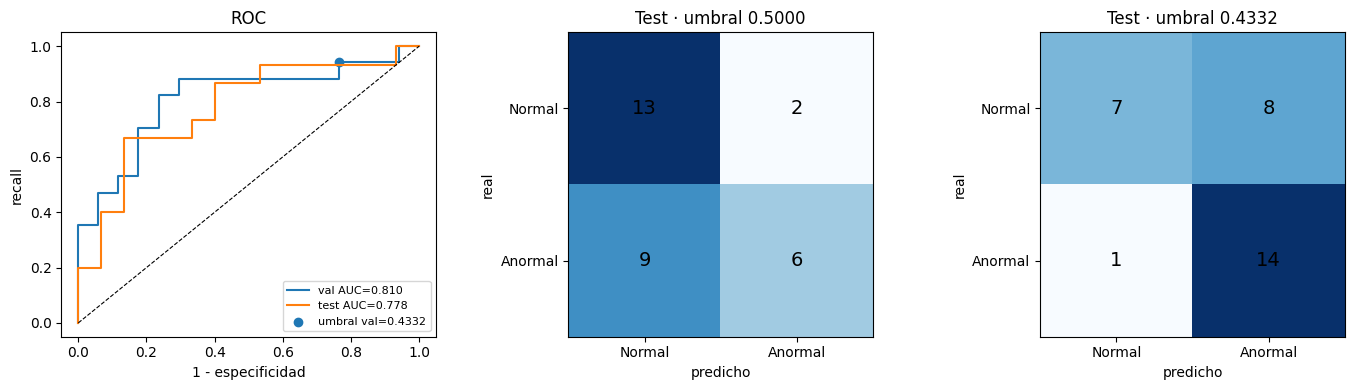

P5_UMBRAL_JSON={"config": {"model": "c_gap", "threshold": 0.43320608139038086, "target_recall": 0.9, "selected_on": "validation only, n=34 (17 positives)", "criterion": "maximum observed threshold reaching validation recall >= 0.90", "validation": {"acc": 0.5882352941176471, "f1": 0.6956521739130435, "recall": 0.9411764705882353, "precision": 0.5517241379310345, "specificity": 0.23529411764705882, "auc": 0.8096885813148789, "TN": 4, "FP": 13, "FN": 1, "TP": 16}, "frozen_at_utc": "2026-10-06T09:08:38.271496+00:00"}, "validation_default": {"acc": 0.7352941176470589, "f1": 0.7096774193548387, "recall": 0.6470588235294118, "precision": 0.7857142857142857, "specificity": 0.8235294117647058, "auc": 0.8096885813148789, "TN": 14, "FP": 3, "FN": 6, "TP": 11}, "test_default": {"acc": 0.6333333333333333, "f1": 0.5217391304347826, "recall": 0.4, "precision": 0.75, "specificity": 0.8666666666666667, "auc": 0.7777777777777777, "TN": 13, "FP": 2, "FN": 9, "TP": 6}, "test_selected": {"acc": 0.7, "f1":

In [25]:
# P5.3 — Umbral elegido solo en validación; luego se aplica sin ajustes al test.
p_val_p5 = np.load(OUT / 'c_gap.p_val.npy')
fpr_p5, tpr_p5, thresholds_p5 = roc_curve(y_val, p_val_p5, drop_intermediate=False)
eligible_p5 = np.flatnonzero((tpr_p5 >= 0.90) & np.isfinite(thresholds_p5))
assert len(eligible_p5) > 0
THRESHOLD_P5 = float(np.max(thresholds_p5[eligible_p5]))
threshold_config_p5 = dict(model=P5_KEY, threshold=THRESHOLD_P5, target_recall=0.90,
    selected_on='validation only, n=34 (17 positives)',
    criterion='maximum observed threshold reaching validation recall >= 0.90',
    validation=metrics_p5(y_val, p_val_p5, THRESHOLD_P5),
    frozen_at_utc=datetime.now(timezone.utc).isoformat())
# Escribimos la decisión antes de evaluar este umbral en test.
(OUT_P5 / 'umbral_fijado.json').write_text(json.dumps(threshold_config_p5, indent=2), encoding='utf-8')
threshold_result_p5 = dict(config=threshold_config_p5,
    validation_default=metrics_p5(y_val, p_val_p5),
    test_default=metrics_p5(y_test, p5_test),
    test_selected=metrics_p5(y_test, p5_test, THRESHOLD_P5))
selected_metrics_p5 = threshold_result_p5['test_selected']
threshold_result_p5['test_selected_wilson95'] = wilson_p5(selected_metrics_p5['TN']+selected_metrics_p5['TP'],len(y_test))
threshold_result_p5['test_selected_recall_wilson95'] = wilson_p5(selected_metrics_p5['TP'],int(np.sum(y_test==1)))
threshold_result_p5['test_selected_FN_indices'] = np.flatnonzero((y_test==1)&(p5_test<THRESHOLD_P5)).tolist()
(OUT_P5 / 'umbral.json').write_text(json.dumps(threshold_result_p5, indent=2), encoding='utf-8')
display(pd.DataFrame([threshold_result_p5['validation_default'],threshold_config_p5['validation'],
    threshold_result_p5['test_default'],threshold_result_p5['test_selected']],
    index=['val @0.5','val @umbral elegido','test @0.5','test @umbral elegido']).round(4))
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
ft, tt, _ = roc_curve(y_test, p5_test)
axes[0].plot(fpr_p5, tpr_p5, label=f'val AUC={roc_auc_score(y_val,p_val_p5):.3f}')
axes[0].plot(ft, tt, label=f'test AUC={roc_auc_score(y_test,p5_test):.3f}')
chosen_index = np.flatnonzero(thresholds_p5 == THRESHOLD_P5)[0]
axes[0].scatter(fpr_p5[chosen_index],tpr_p5[chosen_index],label=f'umbral val={THRESHOLD_P5:.4f}')
axes[0].plot([0,1],[0,1],'k--',lw=0.8)
axes[0].set(xlabel='1 - especificidad',ylabel='recall',title='ROC'); axes[0].legend(fontsize=8)
for ax, threshold in zip(axes[1:], [0.5, THRESHOLD_P5]):
  matrix = confusion_matrix(y_test,(p5_test>=threshold).astype(int),labels=[0,1])
  ax.imshow(matrix,cmap='Blues')
  for (r,c), value in np.ndenumerate(matrix):
    ax.text(c,r,value,ha='center',va='center',fontsize=14)
  ax.set(xticks=[0,1],yticks=[0,1],xticklabels=['Normal','Anormal'],yticklabels=['Normal','Anormal'],
      xlabel='predicho',ylabel='real',title=f'Test · umbral {threshold:.4f}')
fig.tight_layout(); fig.savefig(OUT_P5 / 'umbral_roc_matrices.png',dpi=150); plt.show()
print('P5_UMBRAL_JSON='+json.dumps(threshold_result_p5))

# P5.4 se responde con el FN 28 de P4; la corrección propuesta no se ha entrenado.
archive_p5 = shutil.make_archive('/kaggle/working/p5_resultados','zip',root_dir=str(OUT_P5))
print('Respaldo P5:',archive_p5)


**P5 — Sus respuestas**

**Predicciones previas:** esperaba intervalos amplios, variación entre folds y diferencias BN lote/móviles; GN podría ayudar sin garantía. Bajar el umbral podría reducir FN y aumentar FP. Registradas antes de ejecutar, ubicadas aquí al final.

1. **Fiabilidad →** Test a umbral 0.5: 23/30, **76.67%**, Wilson 95% **[59.07%, 88.21%]**; cada volumen vale 3.33 puntos. Cinco folds: accuracy **0.7176 ± 0.0573**, F1 **0.6595 ± 0.1292**, AUC **0.7405 ± 0.0859** (media ± desviación muestral). GAP sigue siendo provisional: solo esta arquitectura pasó por CV y el fold también seleccionó la época; no demuestra superioridad robusta.
2. **BatchNorm + B=2 →** Entrenando usa estadísticas del lote; al inferir usa medias/varianzas móviles. En Conv3D participan posiciones espaciales, pero solo dos pacientes independientes por lote. Diagnóstico aislado, sin Dropout: Δp medio **0.127**, **6/34** decisiones cambian; pesos originales intactos. Usaría **GroupNorm(8)**, independiente del lote. BN/GN en validación: accuracy **0.765/0.794**, AUC **0.796/0.785**. GN mejora accuracy, F1 y recall, pero reduce AUC y especificidad en esta partición. Mantengo BN según el criterio previo de AUC.
3. **Métrica y costo clínico →** Según el costo de FN de la consigna, priorizaría recall, controlando especificidad/precisión; F1 equilibra precision–recall y AUC evalúa ranking, sin fijar umbral. Umbral **0.32611** elegido solo en val logra recall **16/17=94.12%**. Test: recall **73.33%→93.33%**, FN **4→1**, FP **3→4**, especificidad **80.00%→73.33%**, F1 **0.759→0.848**, accuracy final **83.33%**. AUC sigue **0.920**; no garantiza sensibilidad poblacional≥90%.
4. **Modo de fallo + corrección →** FN 28 predijo Normal (p(Anormal)=0.101) y resaltó camilla/fondo inferior; sigue siendo FN con el nuevo umbral. Propongo máscara pulmonar + recorte 3D con margen, mismo protocolo y comparación de recall/FN y mapas en evaluación independiente. Es un posible atajo; Grad-CAM no demuestra causalidad y esta corrección aún no se entrenó.

**Protocolo:** GAP y checkpoint fijados en P2–P4; bootstrap ordinario, B=2000, semilla 0. CV estratificada 5×136/34, inicio desde cero, B=2, máximo 100 épocas, paciencia 15 por val_acc, mejor checkpoint recargado. GN cambia solo normalización en 136/34. Umbral guardado antes de aplicarlo a test; test no ajusta modelos ni umbral.


---
## Checklist de entrega

- [ ] Notebook ejecutado con las celdas de salida visibles (curvas, tablas, Grad-CAM). No puesto que se ha trabajado por versiones para no perder resultados. 
- [x] Tabla de ablación de P2 completa con sus números.
- [ ] Declaración de uso de IA completada.
- [ ] **Enlace al video de sustentación (≤ 10 min)** pegado arriba. Pendiente. 
- [x] Cuadernos de decisiones de cada parte respondidos.

**Recuerde:** cada parte se acredita solo si puede explicarla en su video. Reporte también lo que no funcionó.